In [2]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter, MaxNLocator
import circlify
import squarify

# Đọc dữ liệu & hàm clean

In [3]:
FILE_PATH = r"D:\Năm3_Kì2\CAP1\DuLieu_Tableau\DuLieu_Phim_2020_2025.xlsx"

movies_main = pd.read_excel(FILE_PATH, sheet_name="movies_main")
movies_genre = pd.read_excel(FILE_PATH, sheet_name="movies_genre")
movies_director = pd.read_excel(FILE_PATH, sheet_name="movies_director")
movies_stars = pd.read_excel(FILE_PATH, sheet_name="movies_stars")
movies_country = pd.read_excel(FILE_PATH, sheet_name="movies_country")

def clean_text_column(df, col):
    out = df.copy()
    out[col] = out[col].astype("string").str.strip()

    invalid = (
        out[col].isna() |
        (out[col] == "") |
        (out[col].str.lower().isin(["unknown", "nan", "none"]))
    )
    return out.loc[~invalid].copy()

# DASHBOARD 1: FILM ANALYTICS OVERVIEW

Chuẩn bị dữ liệu

In [4]:
movies_main["Released_Date"] = pd.to_datetime(movies_main["Released_Date"], errors="coerce")
movies_main["Gross"] = pd.to_numeric(movies_main["Gross"], errors="coerce").fillna(0)
movies_main["Weighted_Rating"] = pd.to_numeric(movies_main["Weighted_Rating"], errors="coerce")
movies_main["month"] = movies_main["Released_Date"].dt.to_period("M").dt.to_timestamp()

monthly_summary = (
    movies_main.groupby("month", as_index=False)
    .agg(
        total_movies=("ID", "nunique"),
        total_gross=("Gross", "sum"),
        avg_weighted_rating=("Weighted_Rating", "mean")
    )
    .sort_values("month")
    .reset_index(drop=True)
)

total_movies = movies_main["ID"].nunique()
total_gross = movies_main["Gross"].sum()
avg_weighted_rate = movies_main["Weighted_Rating"].mean()
total_genre = clean_text_column(movies_genre, "Genre_Name")["Genre_Name"].nunique()

Chart 1: KPI block

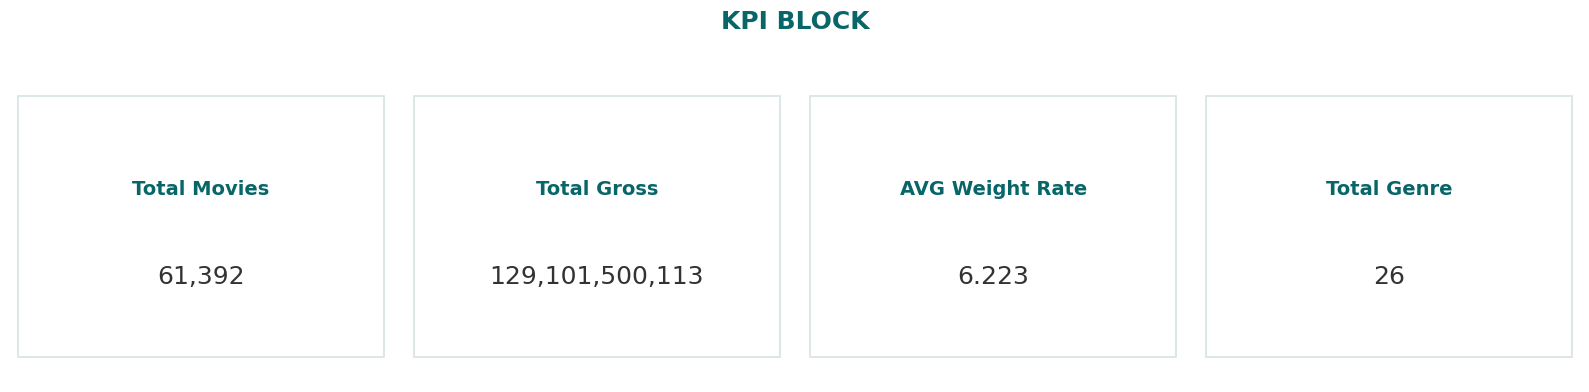

In [5]:
THEME = "#086669"
BG = "white"

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), facecolor=BG)

kpis = [
    ("Total Movies", f"{total_movies:,}"),
    ("Total Gross", f"{total_gross:,.0f}"),
    ("AVG Weight Rate", f"{avg_weighted_rate:.3f}"),
    ("Total Genre", f"{total_genre:,}")
]

for ax, (title, value) in zip(axes, kpis):
    ax.set_facecolor(BG)
    ax.axis("off")

    card = plt.Rectangle(
        (0.02, 0.08), 0.96, 0.84,
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="#D7E3E3",
        linewidth=1.2
    )
    ax.add_patch(card)

    ax.text(
        0.5, 0.62, title,
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        color=THEME, transform=ax.transAxes
    )
    ax.text(
        0.5, 0.34, value,
        ha="center", va="center",
        fontsize=18, color="#333333",
        transform=ax.transAxes
    )

fig.suptitle("KPI BLOCK", fontsize=18, fontweight="bold", color=THEME, y=1.02)
plt.tight_layout()
plt.show()

Chart 2: Line KPI block

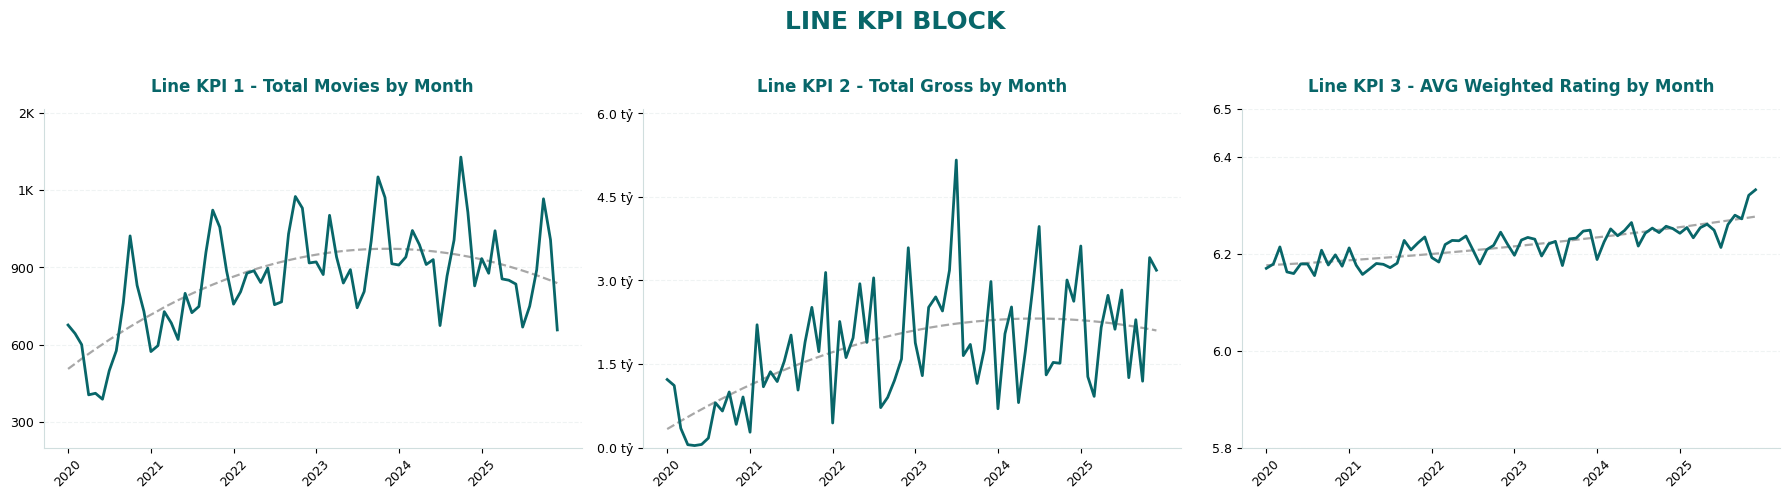

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), facecolor=BG)

series_list = [
    ("Line KPI 1 - Total Movies by Month", monthly_summary["total_movies"]),
    ("Line KPI 2 - Total Gross by Month", monthly_summary["total_gross"]),
    ("Line KPI 3 - AVG Weighted Rating by Month", monthly_summary["avg_weighted_rating"]),
]

def fmt_movies(x, pos):
    if abs(x) >= 1000:
        return f"{x/1000:.0f}K"
    return f"{x:.0f}"

def fmt_billions(x, pos):
    return f"{x/1e9:.1f} tỷ"

def fmt_rating(x, pos):
    return f"{x:.1f}"

for ax, (title, y) in zip(axes, series_list):
    x = monthly_summary["month"]
    y = pd.Series(y).astype(float)

    ax.plot(x, y, color=THEME, linewidth=2.0, zorder=3)

    idx = np.arange(len(y))
    mask = y.notna()
    if mask.sum() >= 3:
        coef = np.polyfit(idx[mask], y[mask], 2)
        trend = np.poly1d(coef)(idx)
        ax.plot(
            x, trend,
            linestyle="--",
            linewidth=1.6,
            color="#9E9E9E",
            alpha=0.9,
            zorder=2
        )

    ax.set_title(title, fontsize=12, color=THEME, fontweight="bold", pad=12)
    ax.set_facecolor(BG)
    ax.grid(axis="y", linestyle="--", alpha=0.22, color="#B7CACA")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0DEDE")
    ax.spines["bottom"].set_color("#D0DEDE")

    ax.tick_params(axis="x", labelsize=9, rotation=45)
    ax.tick_params(axis="y", labelsize=9)

    year_ticks = pd.date_range(x.min(), x.max(), freq="YS")
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([d.year for d in year_ticks])

    ymin = y.min()
    ymax = y.max()
    yrange = ymax - ymin

    if "Total Movies" in title:
        pad = yrange * 0.20 if yrange > 0 else max(abs(ymax) * 0.1, 1)
        ax.set_ylim(ymin - pad, ymax + pad)
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_formatter(FuncFormatter(fmt_movies))

    elif "Total Gross" in title:
        pad = yrange * 0.18 if yrange > 0 else max(abs(ymax) * 0.1, 1)
        ax.set_ylim(max(0, ymin - pad), ymax + pad)
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_formatter(FuncFormatter(fmt_billions))

    elif "Weighted Rating" in title:
        ax.set_ylim(5.8, 6.5)
        ax.set_yticks([5.8, 6.0, 6.2, 6.4, 6.5])
        ax.yaxis.set_major_formatter(FuncFormatter(fmt_rating))

fig.suptitle("LINE KPI BLOCK", fontsize=18, fontweight="bold", color=THEME, y=1.03)
plt.tight_layout()
plt.show()

Chart 3: Bubble chart: Genre Distribution

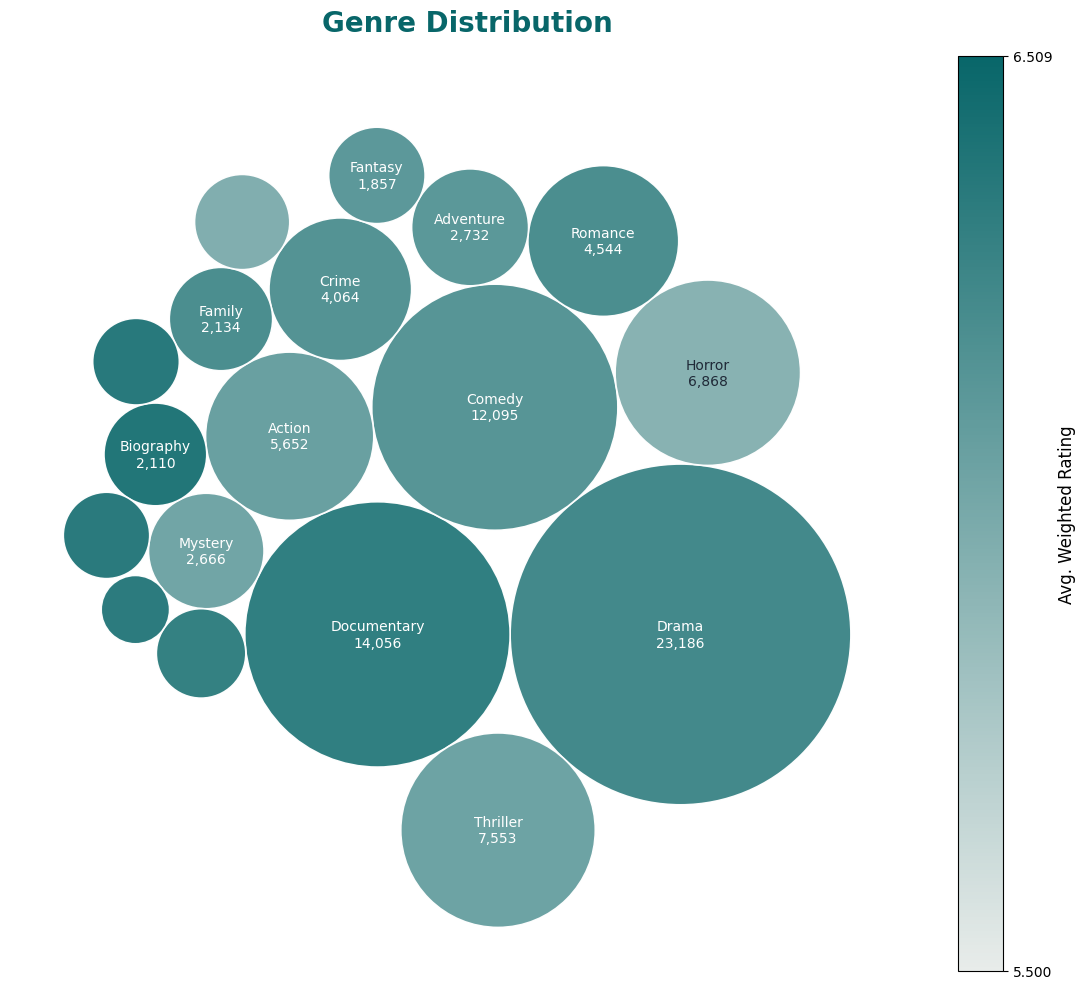

In [7]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

WR_VMIN = 5.5
WR_VMAX = 6.508922410

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "wr_map_dash1_bubble",
    ["#E8ECEA", THEME]
)
wr_norm = mpl.colors.Normalize(vmin=WR_VMIN, vmax=WR_VMAX)

genre_summary = (
    clean_text_column(movies_genre, "Genre_Name")
    .merge(
        movies_main[["ID", "Weighted_Rating"]],
        on="ID",
        how="left"
    )
    .groupby("Genre_Name", as_index=False)
    .agg(
        movie_count=("ID", "nunique"),
        avg_rating=("Weighted_Rating", "mean")
    )
    .sort_values(["movie_count", "Genre_Name"], ascending=[False, True])
    .head(18)
    .reset_index(drop=True)
)

circles = circlify.circlify(
    genre_summary["movie_count"].tolist(),
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)
circles = sorted(circles, key=lambda c: c.r, reverse=True)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
ax.set_facecolor(BG)

ax.set_title("Genre Distribution", fontsize=20, fontweight="bold", color=THEME, pad=18)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.axis("off")

for circle, row in zip(circles, genre_summary.itertuples(index=False)):
    bubble_color = cmap(wr_norm(row.avg_rating))

    ax.add_patch(
        plt.Circle(
            (circle.x, circle.y),
            circle.r,
            facecolor=bubble_color,
            edgecolor="white",
            linewidth=1.2,
            alpha=0.98
        )
    )

    if circle.r >= 0.115:
        txt_color = "white" if wr_norm(row.avg_rating) >= 0.52 else TEXT_DARK
        ax.text(
            circle.x, circle.y,
            f"{row.Genre_Name}\n{row.movie_count:,}",
            ha="center", va="center",
            fontsize=10, color=txt_color
        )

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=wr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Avg. Weighted Rating", fontsize=12)
cbar.set_ticks([WR_VMIN, WR_VMAX])
cbar.set_ticklabels([f"{WR_VMIN:.3f}", f"{WR_VMAX:.3f}"])

plt.tight_layout()
plt.show()

Chart 4: Treemap: Top 10 Release Countries by Number of Movies

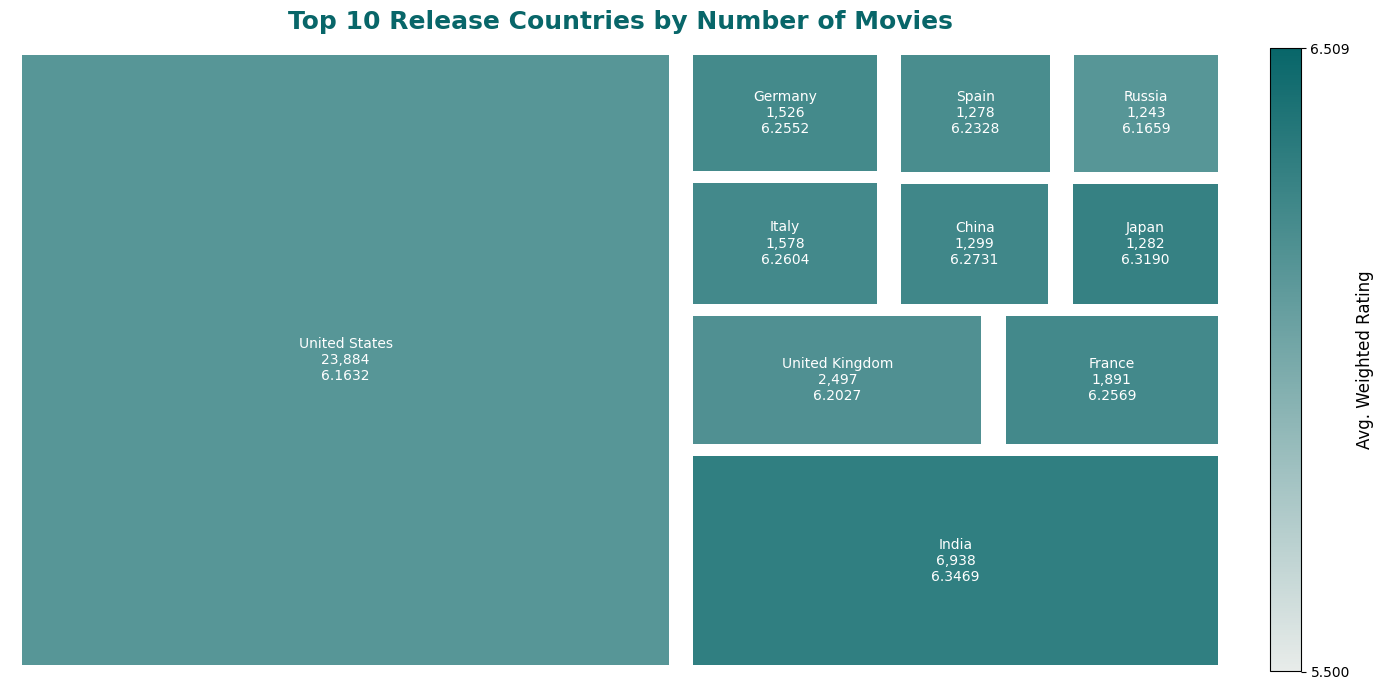

In [8]:
THEME = "#086669"
BG = "white"

WR_VMIN = 5.5
WR_VMAX = 6.508922410

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "wr_map_dash1_treemap",
    ["#E8ECEA", THEME]
)
wr_norm = mpl.colors.Normalize(vmin=WR_VMIN, vmax=WR_VMAX)

country_base = clean_text_column(movies_main, "Release_Country")

country_summary = (
    country_base.groupby("Release_Country", as_index=False)
    .agg(
        movie_count=("ID", "nunique"),
        avg_rating=("Weighted_Rating", "mean")
    )
    .sort_values(["movie_count", "Release_Country"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

labels = [
    f"{row.Release_Country}\n{row.movie_count:,}\n{row.avg_rating:.4f}"
    for row in country_summary.itertuples(index=False)
]

colors = [cmap(wr_norm(v)) for v in country_summary["avg_rating"]]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_facecolor(BG)

squarify.plot(
    sizes=country_summary["movie_count"],
    label=labels,
    color=colors,
    alpha=0.98,
    pad=True,
    text_kwargs={"fontsize": 10, "color": "white"},
    ax=ax
)

ax.set_title(
    "Top 10 Release Countries by Number of Movies",
    fontsize=18, fontweight="bold", color=THEME, pad=14
)
ax.axis("off")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=wr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Avg. Weighted Rating", fontsize=12)
cbar.set_ticks([WR_VMIN, WR_VMAX])
cbar.set_ticklabels([f"{WR_VMIN:.3f}", f"{WR_VMAX:.3f}"])

plt.tight_layout()
plt.show()

Chart 5.1: Lollipop chart: Top 10 Stars by Movies

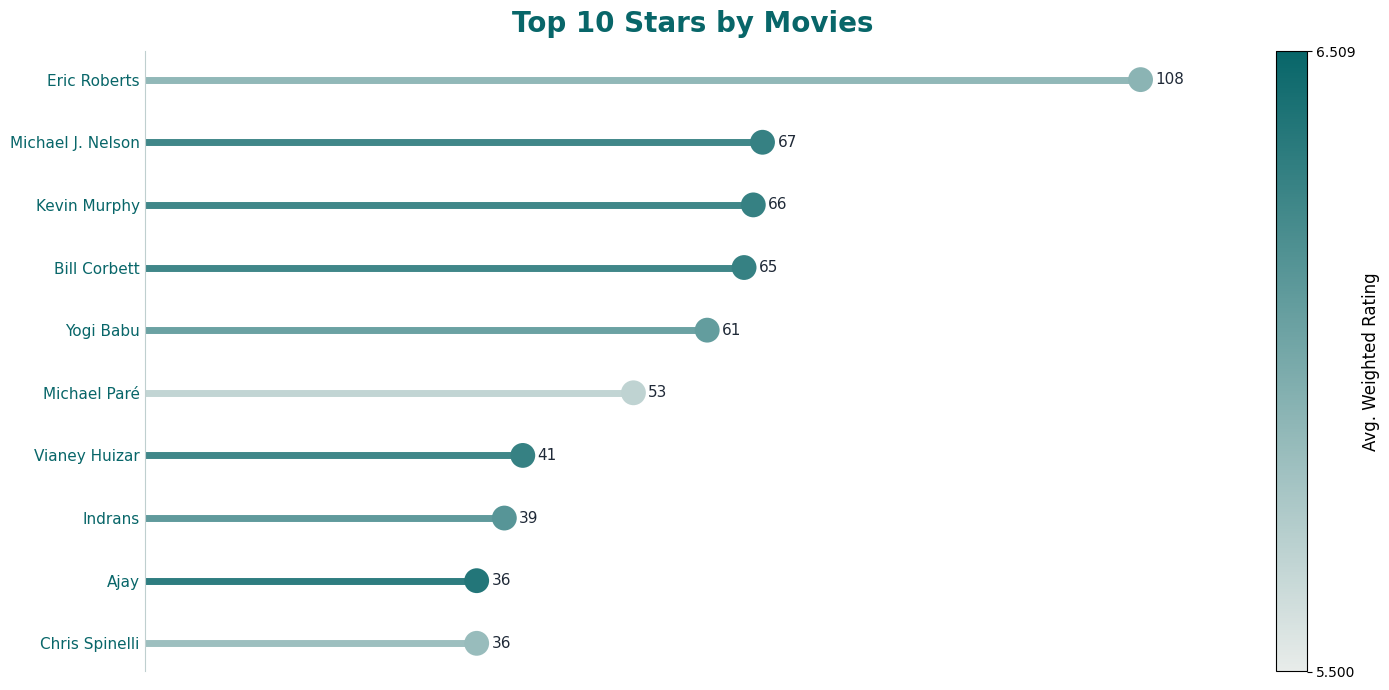

In [9]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

WR_VMIN = 5.5
WR_VMAX = 6.508922410

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "wr_map_dash1_stars",
    ["#E8ECEA", THEME]
)
wr_norm = mpl.colors.Normalize(vmin=WR_VMIN, vmax=WR_VMAX)

star_summary = (
    clean_text_column(movies_stars, "Star_Name")
    .merge(
        movies_main[["ID", "Weighted_Rating"]],
        on="ID",
        how="left"
    )
    .groupby("Star_Name", as_index=False)
    .agg(
        movie_count=("ID", "nunique"),
        avg_rating=("Weighted_Rating", "mean")
    )
    .sort_values(["movie_count", "Star_Name"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

plot_df = star_summary.sort_values("movie_count", ascending=False).reset_index(drop=True)
y = np.arange(len(plot_df))
colors = [cmap(wr_norm(v)) for v in plot_df["avg_rating"]]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_facecolor(BG)

ax.hlines(y=y, xmin=0, xmax=plot_df["movie_count"], color=colors, linewidth=5, alpha=0.95, zorder=2)
ax.scatter(plot_df["movie_count"], y, s=320, color=colors, edgecolor="none", zorder=3)

offset = plot_df["movie_count"].max() * 0.015
for yi, xi in zip(y, plot_df["movie_count"]):
    ax.text(
        xi + offset, yi,
        f"{int(xi):,}",
        va="center", ha="left",
        fontsize=11, color=TEXT_DARK
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Star_Name"], fontsize=11, color=THEME)
ax.set_title("Top 10 Stars by Movies", fontsize=20, fontweight="bold", color=THEME, pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#BFCFCF")

ax.set_xticks([])
ax.tick_params(axis="y", length=0)
ax.grid(False)
ax.invert_yaxis()
ax.set_xlim(0, plot_df["movie_count"].max() * 1.10)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=wr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Avg. Weighted Rating", fontsize=12)
cbar.set_ticks([WR_VMIN, WR_VMAX])
cbar.set_ticklabels([f"{WR_VMIN:.3f}", f"{WR_VMAX:.3f}"])

plt.tight_layout()
plt.show()

Chart 5.2: Lollipop chart: Top 10 Directors by Movies

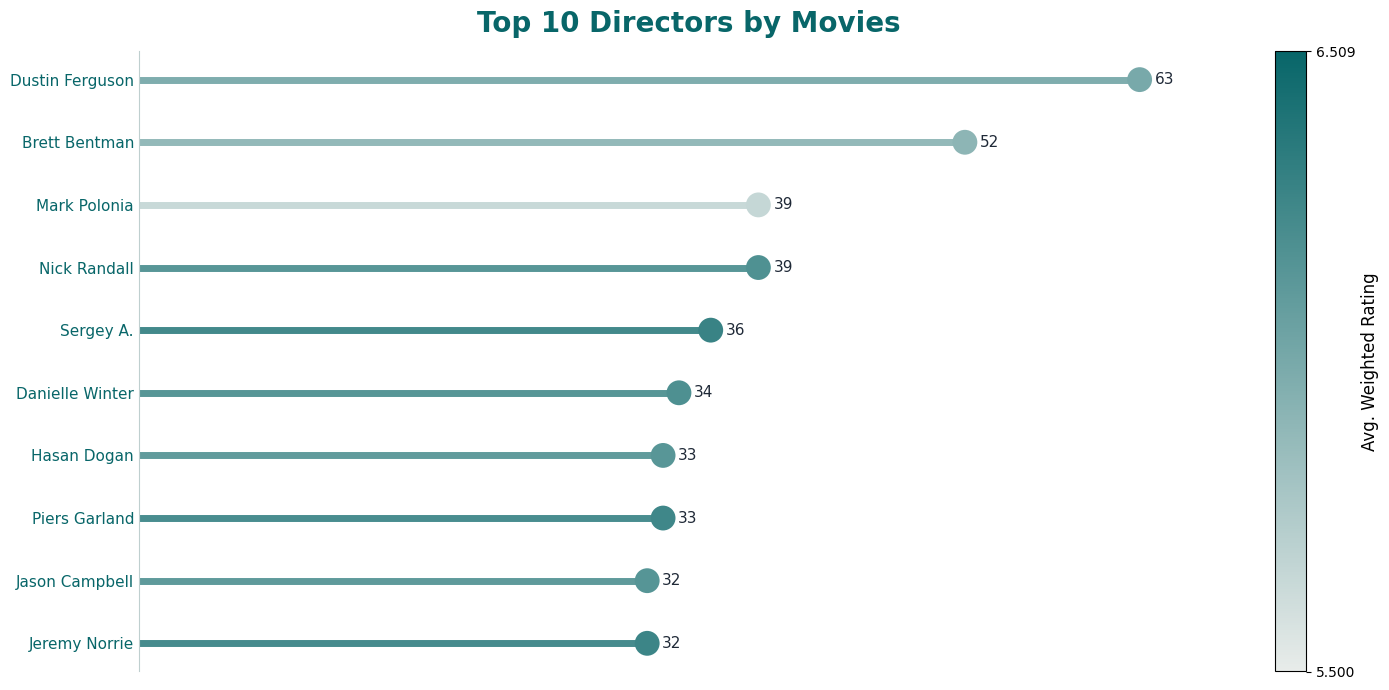

In [10]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

WR_VMIN = 5.5
WR_VMAX = 6.508922410

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "wr_map_dash1_directors",
    ["#E8ECEA", THEME]
)
wr_norm = mpl.colors.Normalize(vmin=WR_VMIN, vmax=WR_VMAX)

director_summary = (
    clean_text_column(movies_director, "Director_Name")
    .merge(
        movies_main[["ID", "Weighted_Rating"]],
        on="ID",
        how="left"
    )
    .groupby("Director_Name", as_index=False)
    .agg(
        movie_count=("ID", "nunique"),
        avg_rating=("Weighted_Rating", "mean")
    )
    .sort_values(["movie_count", "Director_Name"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

plot_df = director_summary.sort_values("movie_count", ascending=False).reset_index(drop=True)
y = np.arange(len(plot_df))
colors = [cmap(wr_norm(v)) for v in plot_df["avg_rating"]]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_facecolor(BG)

ax.hlines(y=y, xmin=0, xmax=plot_df["movie_count"], color=colors, linewidth=5, alpha=0.95, zorder=2)
ax.scatter(plot_df["movie_count"], y, s=320, color=colors, edgecolor="none", zorder=3)

offset = plot_df["movie_count"].max() * 0.015
for yi, xi in zip(y, plot_df["movie_count"]):
    ax.text(
        xi + offset, yi,
        f"{int(xi):,}",
        va="center", ha="left",
        fontsize=11, color=TEXT_DARK
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Director_Name"], fontsize=11, color=THEME)
ax.set_title("Top 10 Directors by Movies", fontsize=20, fontweight="bold", color=THEME, pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#BFCFCF")

ax.set_xticks([])
ax.tick_params(axis="y", length=0)
ax.grid(False)
ax.invert_yaxis()
ax.set_xlim(0, plot_df["movie_count"].max() * 1.10)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=wr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Avg. Weighted Rating", fontsize=12)
cbar.set_ticks([WR_VMIN, WR_VMAX])
cbar.set_ticklabels([f"{WR_VMIN:.3f}", f"{WR_VMAX:.3f}"])

plt.tight_layout()
plt.show()

# DASHBOARD 2: MOVIE GENRE ANALYTICS 

Chart 1: Number of Movies by Genre

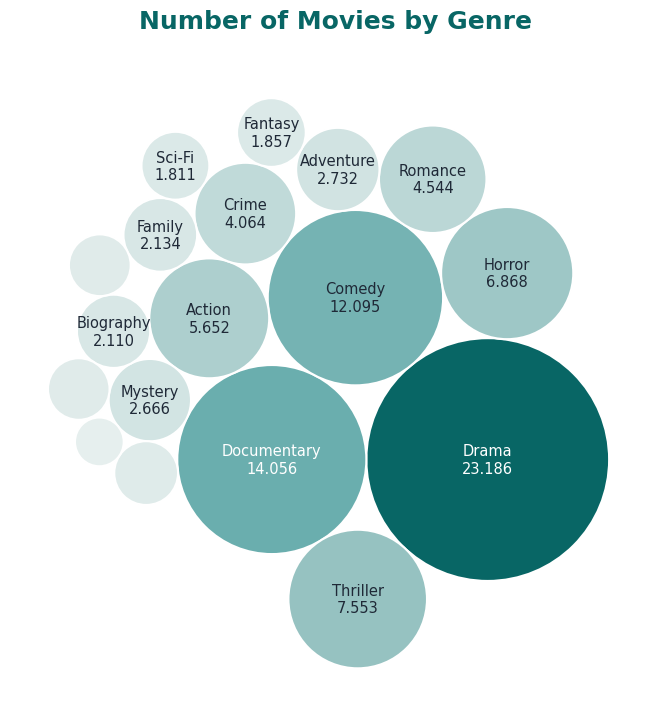

In [11]:
genre_plot = (
    clean_text_column(movies_genre, "Genre_Name")
    .groupby("Genre_Name", as_index=False)
    .agg(movie_count=("ID", "nunique"))
    .sort_values(["movie_count", "Genre_Name"], ascending=[False, True])
    .head(18)
    .reset_index(drop=True)
)

circles = circlify.circlify(
    genre_plot["movie_count"].tolist(),
    show_enclosure=False,
    target_enclosure=circlify.Circle(x=0, y=0, r=1)
)
circles = sorted(circles, key=lambda c: c.r, reverse=True)

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "teal_grad_d2_chart1",
    ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
)
norm = mpl.colors.Normalize(
    vmin=genre_plot["movie_count"].min(),
    vmax=genre_plot["movie_count"].max()
)

fmt_thousands_dot = lambda n: f"{int(round(n)):,}".replace(",", ".")
wrap_text_local = lambda s, width=12: "\n".join(textwrap.wrap(str(s), width=width))

fig, ax = plt.subplots(figsize=(8, 7.2), facecolor=BG)
ax.set_facecolor(BG)
ax.set_title("Number of Movies by Genre", fontsize=18, fontweight="bold", color="#086665", pad=14)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.axis("off")

for circle, row in zip(circles, genre_plot.itertuples(index=False)):
    color = cmap(norm(row.movie_count))
    ax.add_patch(
        plt.Circle(
            (circle.x, circle.y),
            circle.r,
            facecolor=color,
            edgecolor="white",
            linewidth=1.5
        )
    )
    if circle.r >= 0.11:
        txt_color = "white" if norm(row.movie_count) >= 0.52 else TEXT_DARK
        ax.text(
            circle.x, circle.y,
            f"{wrap_text_local(row.Genre_Name, 12)}\n{fmt_thousands_dot(row.movie_count)}",
            ha="center", va="center",
            fontsize=10.5, color=txt_color
        )

plt.tight_layout()
plt.show()

Chart 2: Genre Trends Over Time

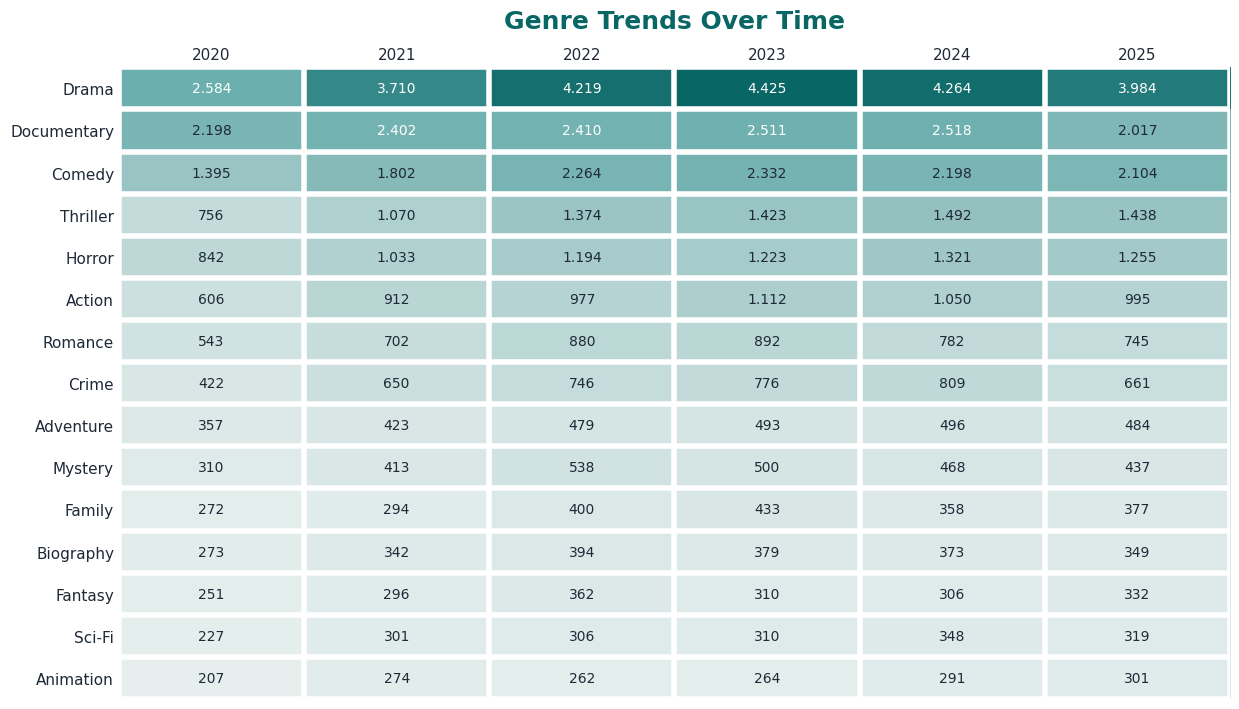

In [12]:
genre_order_fixed = [
    "Drama", "Documentary", "Comedy", "Thriller", "Horror",
    "Action", "Romance", "Crime", "Adventure", "Mystery",
    "Family", "Biography", "Fantasy", "Sci-Fi", "Animation",
]

genre_year_matrix = (
    clean_text_column(movies_genre[["ID", "Genre_Name"]].copy(), "Genre_Name")
    .merge(
        movies_main.assign(
            Released_Date=pd.to_datetime(movies_main["Released_Date"], errors="coerce"),
            Year=pd.to_datetime(movies_main["Released_Date"], errors="coerce").dt.year
        )[["ID", "Year"]],
        on="ID",
        how="inner"
    )
)

genre_year_matrix = genre_year_matrix[
    genre_year_matrix["Genre_Name"].isin(genre_order_fixed) &
    genre_year_matrix["Year"].notna()
].copy()

genre_year_matrix = (
    genre_year_matrix.groupby(["Genre_Name", "Year"], as_index=False)
    .agg(movie_count=("ID", "nunique"))
    .pivot(index="Genre_Name", columns="Year", values="movie_count")
    .fillna(0)
    .astype(int)
)

genre_year_matrix = genre_year_matrix.reindex(sorted(genre_year_matrix.columns), axis=1)
genre_year_matrix = genre_year_matrix.reindex([g for g in genre_order_fixed if g in genre_year_matrix.index])

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "teal_grad_d2_chart2",
    ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
)

values = genre_year_matrix.values
norm = mpl.colors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
fmt_thousands_dot = lambda n: f"{int(round(n)):,}".replace(",", ".")

fig, ax = plt.subplots(figsize=(12.5, 7.2), facecolor=BG)
ax.set_facecolor(BG)

ax.imshow(values, aspect="auto", cmap=cmap, interpolation="nearest")

ax.set_title("Genre Trends Over Time", fontsize=18, fontweight="bold", color="#086665", pad=14)
ax.set_xticks(np.arange(genre_year_matrix.shape[1]))
ax.set_xticklabels(genre_year_matrix.columns, fontsize=11, color=TEXT_DARK)
ax.set_yticks(np.arange(genre_year_matrix.shape[0]))
ax.set_yticklabels(genre_year_matrix.index, fontsize=11, color=TEXT_DARK)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)

ax.set_xticks(np.arange(-0.5, genre_year_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, genre_year_matrix.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=4)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(genre_year_matrix.shape[0]):
    for j in range(genre_year_matrix.shape[1]):
        val = values[i, j]
        txt_color = "white" if norm(val) >= 0.52 else TEXT_DARK
        ax.text(
            j, i,
            fmt_thousands_dot(val),
            ha="center", va="center",
            fontsize=10, color=txt_color
        )

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Chart 3 + 4: Top 3 Movies By Gross / Rating

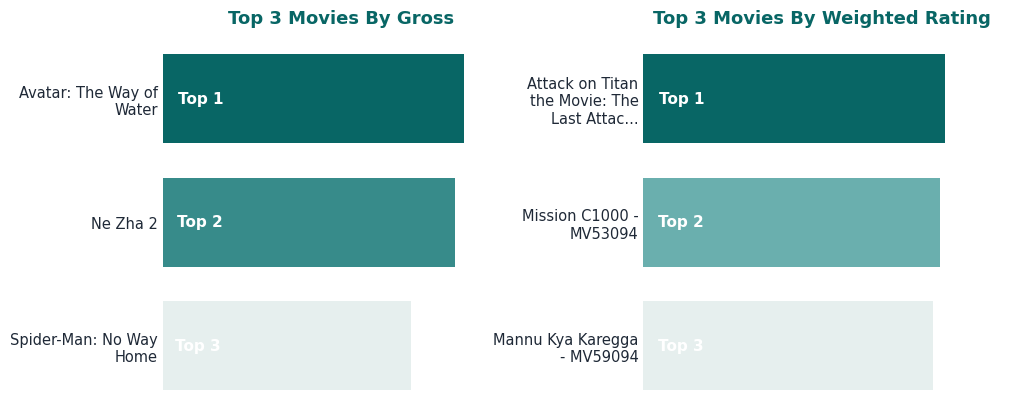

In [57]:
chart3_df = (
    movies_main[(movies_main["has_gross"] == 1) & (movies_main["Gross"].notna())]
    .groupby("Movie_Title", as_index=False)
    .agg(total_gross=("Gross", "sum"))
    .sort_values("total_gross", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

chart4_df = (
    movies_main.dropna(subset=["Movie_Title", "Weighted_Rating", "ID"])
    .assign(Movie_Label=lambda d: d["Movie_Title"].astype(str).str.strip() + " - " + d["ID"].astype(str))
    .groupby("Movie_Label", as_index=False)
    .agg(weighted_rating=("Weighted_Rating", "mean"))
    .sort_values("weighted_rating", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

def ellipsis_wrap_local(s, width=22, max_lines=3):
    parts = textwrap.wrap(str(s), width=width)
    if len(parts) > max_lines:
        parts = parts[:max_lines]
        parts[-1] = (parts[-1][:-3] + "...") if len(parts[-1]) >= 3 else (parts[-1] + "...")
    return "\n".join(parts)

def draw_rank_card_bar_local(ax, labels, values, title):
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "teal_grad_d2_chart34",
        ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
    )
    values_arr = np.asarray(values, dtype=float)
    norm = mpl.colors.Normalize(vmin=np.nanmin(values_arr), vmax=np.nanmax(values_arr)) if len(values_arr) else mpl.colors.Normalize(0, 1)
    colors = [cmap(norm(v)) for v in values_arr]

    y = np.arange(len(labels))
    ax.barh(y, values_arr, color=colors, edgecolor="none", height=0.72)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=13, fontweight="bold", color="#086665", pad=10)
    ax.set_yticks(y)
    ax.set_yticklabels([ellipsis_wrap_local(x, 18, 3) for x in labels], fontsize=10.5, color="#1F2937")
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.set_xlim(0, max(values_arr) * 1.18 if len(values_arr) else 1)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i, v in enumerate(values_arr):
        ax.text(v * 0.05, i, f"Top {i+1}", va="center", ha="left", fontsize=11, color="white", fontweight="bold")

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8), facecolor=BG, gridspec_kw={"wspace": 0.35})
draw_rank_card_bar_local(axes[0], chart3_df["Movie_Title"].tolist(), chart3_df["total_gross"].tolist(), "Top 3 Movies By Gross")
draw_rank_card_bar_local(
    axes[1],
    chart4_df["Movie_Label"].tolist(),
    chart4_df["weighted_rating"].tolist(),
    "Top 3 Movies By Weighted Rating"
)
fig.subplots_adjust(top=0.88, wspace=0.03)
plt.show()

Chart 5: Top 10 Genres by Average Revenue

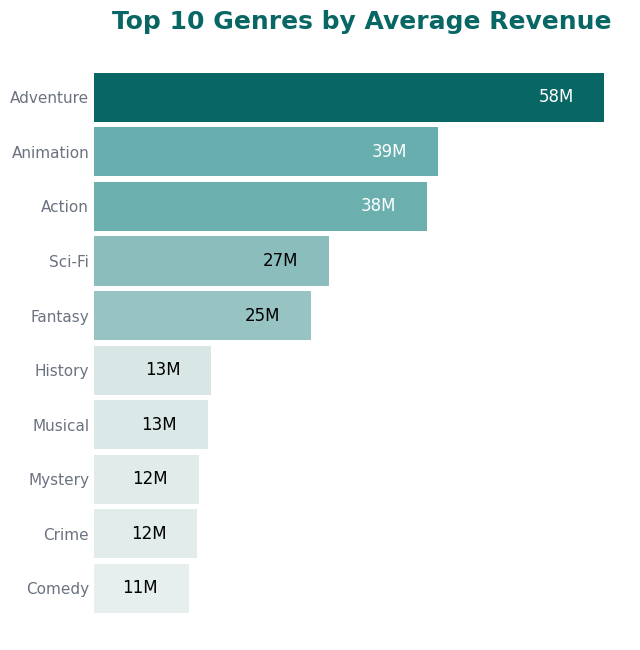

In [14]:
chart5_df = (
    movies_main[
        ["ID", "Gross", "has_gross"]
    ]
    .merge(
        clean_text_column(movies_genre[["ID", "Genre_Name"]].copy(), "Genre_Name"),
        on="ID",
        how="inner"
    )
)

chart5_df = chart5_df[
    (chart5_df["has_gross"] == 1) &
    (chart5_df["Gross"].notna())
].copy()

chart5_df = (
    chart5_df.groupby("Genre_Name", as_index=False)
    .agg(
        total_gross=("Gross", "sum"),
        movie_count=("ID", "nunique")
    )
)

chart5_df["avg_gross"] = chart5_df["total_gross"] / chart5_df["movie_count"]
chart5_df = chart5_df.sort_values("avg_gross", ascending=False).head(10).reset_index(drop=True)

plot_df = chart5_df.sort_values("avg_gross", ascending=True).copy()
values = plot_df["avg_gross"].values
labels = plot_df["Genre_Name"].values

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "teal_grad_d2_chart5",
    ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
)
norm = mpl.colors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
colors = [cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(6.5, 6.6), facecolor=BG)
ax.set_facecolor(BG)

y = np.arange(len(plot_df))
ax.barh(y, values, color=colors, edgecolor="none", height=0.9)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11, color="#6B7280")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.set_title("Top 10 Genres by Average Revenue", fontsize=18, fontweight="bold", color="#086665", pad=12)
ax.set_xlim(0, plot_df["avg_gross"].max() * 1.05)

for spine in ax.spines.values():
    spine.set_visible(False)

max_val = plot_df["avg_gross"].max()
for i, v in enumerate(values):
    text_color = "white" if norm(v) >= 0.50 else "black"
    x_pos = v - max_val * 0.06 if v > max_val * 0.18 else v + max_val * 0.02
    ha = "right" if v > max_val * 0.18 else "left"
    ax.text(x_pos, i, f"{v/1_000_000:.0f}M", va="center", ha=ha, fontsize=12, color=text_color)

plt.tight_layout()
plt.show()

Chart 6: The Pareto of Genres

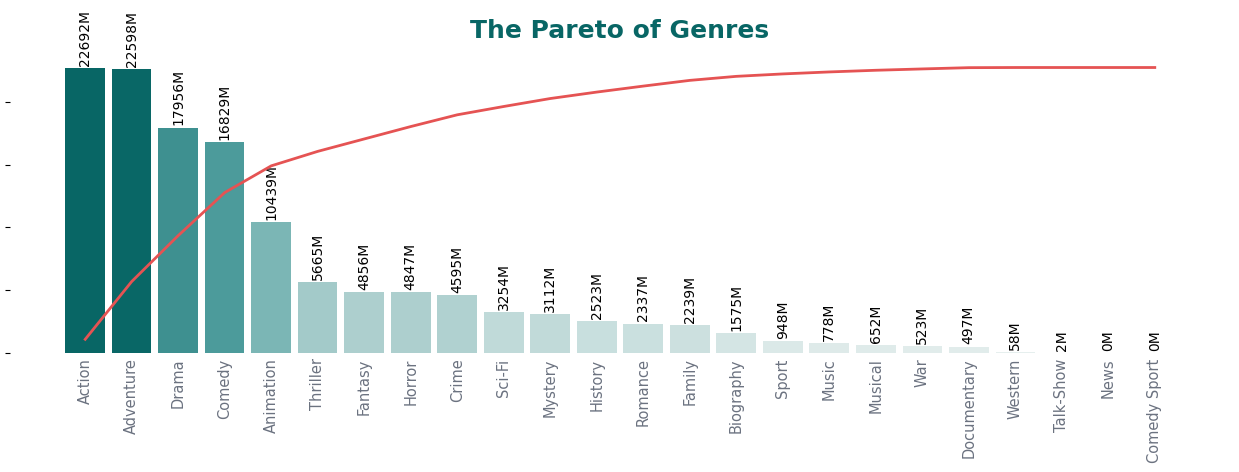

In [15]:
chart6_df = (
    movies_main[
        ["ID", "Gross", "has_gross"]
    ]
    .merge(
        clean_text_column(movies_genre[["ID", "Genre_Name"]].copy(), "Genre_Name"),
        on="ID",
        how="inner"
    )
)

chart6_df = chart6_df[
    (chart6_df["has_gross"] == 1) &
    (chart6_df["Gross"].notna())
].copy()

genre_per_movie = (
    chart6_df.groupby("ID", as_index=False)
    .agg(dem_genre_phim=("Genre_Name", "nunique"))
)

chart6_df = chart6_df.merge(genre_per_movie, on="ID", how="left")
chart6_df["allocated_gross"] = chart6_df["Gross"] / chart6_df["dem_genre_phim"]

chart6_df = (
    chart6_df.groupby("Genre_Name", as_index=False)
    .agg(total_allocated_gross=("allocated_gross", "sum"))
    .sort_values("total_allocated_gross", ascending=False)
    .reset_index(drop=True)
)
chart6_df["cum_gross"] = chart6_df["total_allocated_gross"].cumsum()

x = np.arange(len(chart6_df))
values = chart6_df["total_allocated_gross"].values
labels = chart6_df["Genre_Name"].values

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "teal_grad_d2_chart6",
    ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
)
norm = mpl.colors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
colors = [cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(12.5, 4.8), facecolor=BG)
ax.set_facecolor(BG)

ax.bar(x, values, color=colors, width=0.85, edgecolor="none")
ax.set_title("The Pareto of Genres", fontsize=18, fontweight="bold", color="#086665", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=10.5, color="#6B7280")
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", left=False, labelleft=False)

for spine in ax.spines.values():
    spine.set_visible(False)

max_val = values.max() if len(values) else 1
for i, v in enumerate(values):
    ax.text(i, v + max_val * 0.01, f"{v/1_000_000:.0f}M", ha="center", va="bottom", rotation=90, fontsize=10)

ax2 = ax.twinx()
ax2.plot(x, chart6_df["cum_gross"].values, color="#E55353", linewidth=2)
ax2.tick_params(axis="y", right=False, labelright=False)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Chart 7: Genre Performance: Rating, Revenue, and Audience Interest

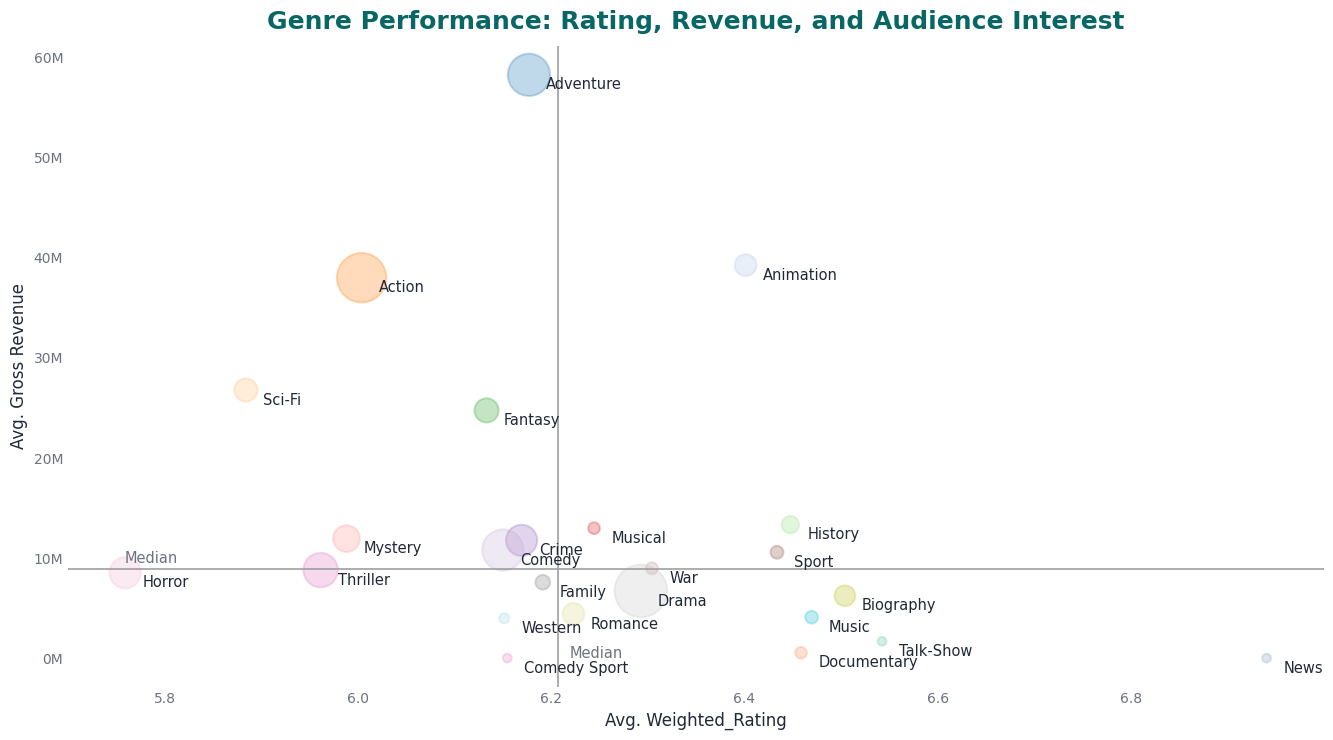

In [16]:
chart7_df = (
    movies_main[
        ["ID", "Gross", "has_gross", "Weighted_Rating", "No_of_votes"]
    ]
    .merge(
        clean_text_column(movies_genre[["ID", "Genre_Name"]].copy(), "Genre_Name"),
        on="ID",
        how="inner"
    )
)

chart7_df = chart7_df[
    (chart7_df["has_gross"] == 1) &
    (chart7_df["Gross"].notna())
].copy()

chart7_df = (
    chart7_df.groupby("Genre_Name", as_index=False)
    .agg(
        avg_gross=("Gross", "mean"),
        avg_weighted_rating=("Weighted_Rating", "mean"),
        total_votes=("No_of_votes", "sum"),
        movie_count=("ID", "nunique")
    )
    .sort_values("avg_gross", ascending=False)
    .reset_index(drop=True)
)

color_list = list(plt.cm.tab20.colors) + list(plt.cm.Set2.colors) + list(plt.cm.Set3.colors)
genre_names = chart7_df["Genre_Name"].tolist()
color_map = {g: color_list[i % len(color_list)] for i, g in enumerate(genre_names)}
colors = [color_map[g] for g in genre_names]

votes = chart7_df["total_votes"].fillna(0).values.astype(float)
if votes.max() == votes.min():
    sizes = np.full_like(votes, 400.0)
else:
    sizes = 40 + 1400 * (votes - votes.min()) / (votes.max() - votes.min())

fmt_millions_local = lambda x, pos=None: f"{x/1_000_000:.0f}M"

fig, ax = plt.subplots(figsize=(13.5, 7.5), facecolor=BG)
ax.set_facecolor(BG)

ax.scatter(
    chart7_df["avg_weighted_rating"],
    chart7_df["avg_gross"],
    s=sizes,
    c=colors,
    alpha=0.28,
    edgecolors=colors,
    linewidths=1.4
)

ax.set_title(
    "Genre Performance: Rating, Revenue, and Audience Interest",
    fontsize=18, fontweight="bold", color="#086665", pad=12
)
ax.set_xlabel("Avg. Weighted_Rating", fontsize=12, color=TEXT_DARK)
ax.set_ylabel("Avg. Gross Revenue", fontsize=12, color=TEXT_DARK)
ax.yaxis.set_major_formatter(FuncFormatter(fmt_millions_local))
ax.tick_params(axis="both", colors="#6B7280", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

x_med = chart7_df["avg_weighted_rating"].median()
y_med = chart7_df["avg_gross"].median()
ax.axvline(x_med, linewidth=1.2, color="#9E9E9E")
ax.axhline(y_med, linewidth=1.2, color="#9E9E9E")

x_range = chart7_df["avg_weighted_rating"].max() - chart7_df["avg_weighted_rating"].min()
y_range = chart7_df["avg_gross"].max() - chart7_df["avg_gross"].min()

for row in chart7_df.itertuples(index=False):
    ax.text(
        row.avg_weighted_rating + x_range * 0.015,
        row.avg_gross - y_range * 0.025,
        row.Genre_Name,
        fontsize=10.5,
        color=TEXT_DARK
    )

ax.text(chart7_df["avg_weighted_rating"].min(), y_med + y_range * 0.01, "Median", color="#6B7280", fontsize=10.5)
ax.text(x_med + x_range * 0.01, chart7_df["avg_gross"].min(), "Median", color="#6B7280", fontsize=10.5)

plt.tight_layout()
plt.show()

# DASHBOARD 3: COUNTRY ANALYTICS

Chart 1: Movie Count by Release Country

In [17]:
chart1_country_count = (
    clean_text_column(movies_country[["ID", "Country_of_Origin"]].copy(), "Country_of_Origin")
    .groupby("Country_of_Origin", as_index=False)
    .agg(movie_count=("ID", "nunique"))
    .sort_values("movie_count", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

chart1_country_count

,Country_of_Origin,movie_count
0,United States,20146
1,India,7500
2,United Kingdom,4428
3,France,3076
4,Canada,2164
5,Germany,2101
6,Italy,2066
7,Spain,1685
8,Japan,1593
9,China,1570


Chart 2: Total Revenue by Release Country

In [18]:
normalize_korea = lambda x: "Korea" if pd.notna(x) and "korea" in str(x).strip().lower() else x

country_gross_base = (
    movies_main[["ID", "Gross", "has_gross"]]
    .merge(movies_country[["ID", "Country_of_Origin"]], on="ID", how="inner")
)

country_gross_base = country_gross_base[
    (country_gross_base["has_gross"] == 1) &
    (country_gross_base["Gross"].notna())
].copy()

country_gross_base["Country_of_Origin"] = country_gross_base["Country_of_Origin"].map(normalize_korea)

chart2_country_gross = (
    clean_text_column(country_gross_base, "Country_of_Origin")
    .groupby("Country_of_Origin", as_index=False)
    .agg(total_gross=("Gross", "sum"))
    .sort_values("total_gross", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

chart2_country_gross

,Country_of_Origin,total_gross
0,United States,9.015004e+10
1,Canada,2.795357e+10
2,China,2.391747e+10
3,United Kingdom,2.121193e+10
4,Japan,1.665271e+10
5,Australia,9.450485e+09
6,New Zealand,5.622188e+09
7,France,5.473855e+09
8,India,3.624981e+09
9,Hungary,3.052660e+09


Chart 3: Avg Rating by Release Country

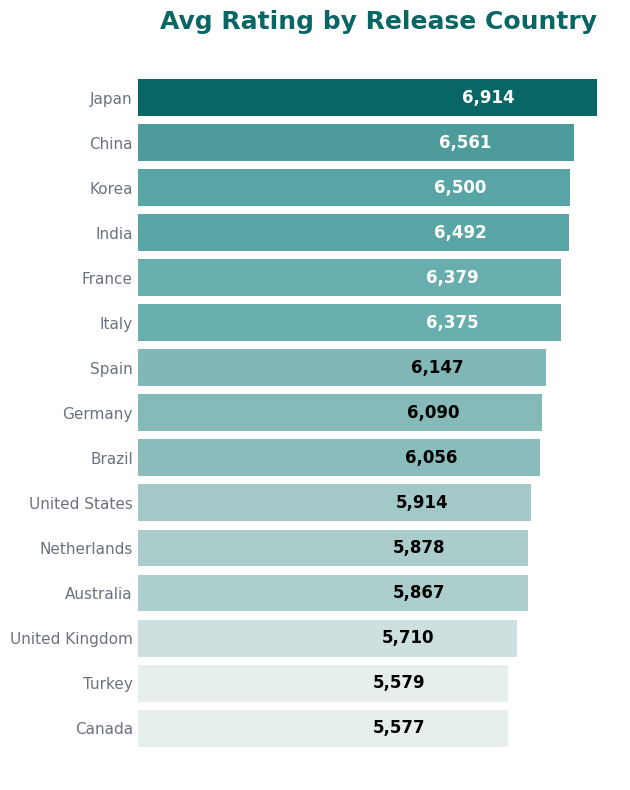

In [59]:
normalize_korea = lambda x: "Korea" if pd.notna(x) and "korea" in str(x).strip().lower() else x
wrap_text_local = lambda s, width=14: "\n".join(textwrap.wrap(str(s), width=width))

chart3_country_rating = (
    movies_main[["ID", "IMDB_Rating", "No_of_votes", "Release_Country"]]
    .copy()
)

chart3_country_rating = chart3_country_rating[
    (chart3_country_rating["No_of_votes"] >= 1000) &
    (chart3_country_rating["IMDB_Rating"].notna()) &
    (chart3_country_rating["Release_Country"].notna())
].copy()

chart3_country_rating["Release_Country"] = chart3_country_rating["Release_Country"].map(normalize_korea)

chart3_country_rating = (
    clean_text_column(chart3_country_rating, "Release_Country")
    .groupby("Release_Country", as_index=False)
    .agg(
        avg_imdb_rating=("IMDB_Rating", "mean"),
        movie_count=("ID", "nunique")
    )
)

chart3_country_rating = (
    chart3_country_rating[chart3_country_rating["movie_count"] >= 50]
    .sort_values("avg_imdb_rating", ascending=False)
    .reset_index(drop=True)
)

plot_df = chart3_country_rating.head(15).sort_values("avg_imdb_rating", ascending=True).copy()
values = plot_df["avg_imdb_rating"].values
labels = plot_df["Release_Country"].values

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "teal_grad_d3_chart3",
    ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
)
norm = mpl.colors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
colors = [cmap(norm(v)) for v in values]

fig, ax = plt.subplots(figsize=(6.4, 8.0), facecolor=BG)
ax.set_facecolor(BG)

y = np.arange(len(plot_df))
ax.barh(y, values, color=colors, edgecolor="none", height=0.82)

ax.set_yticks(y)
ax.set_yticklabels([wrap_text_local(x, 14) for x in labels], fontsize=11, color="#6B7280")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", bottom=False, labelbottom=False)
ax.set_title("Avg Rating by Release Country", fontsize=18, fontweight="bold", color="#086665", pad=12)
ax.set_xlim(0, max(values) * 1.05 if len(values) else 1)

for spine in ax.spines.values():
    spine.set_visible(False)

max_val = max(values) if len(values) else 1
for i, v in enumerate(values):
    text_color = "white" if norm(v) >= 0.50 else "black"
    x_pos = v - max_val * 0.18 if v > max_val * 0.20 else v + max_val * 0.03
    ha = "right" if v > max_val * 0.20 else "left"
    ax.text(
        x_pos, i,
        f"{v:.3f}".replace(".", ","),
        va="center", ha=ha,
        fontsize=12,
        color=text_color,
        fontweight="bold" if ha == "right" else "normal"
    )

plt.tight_layout()
plt.show()

Chart 4: Genre Trends by Country

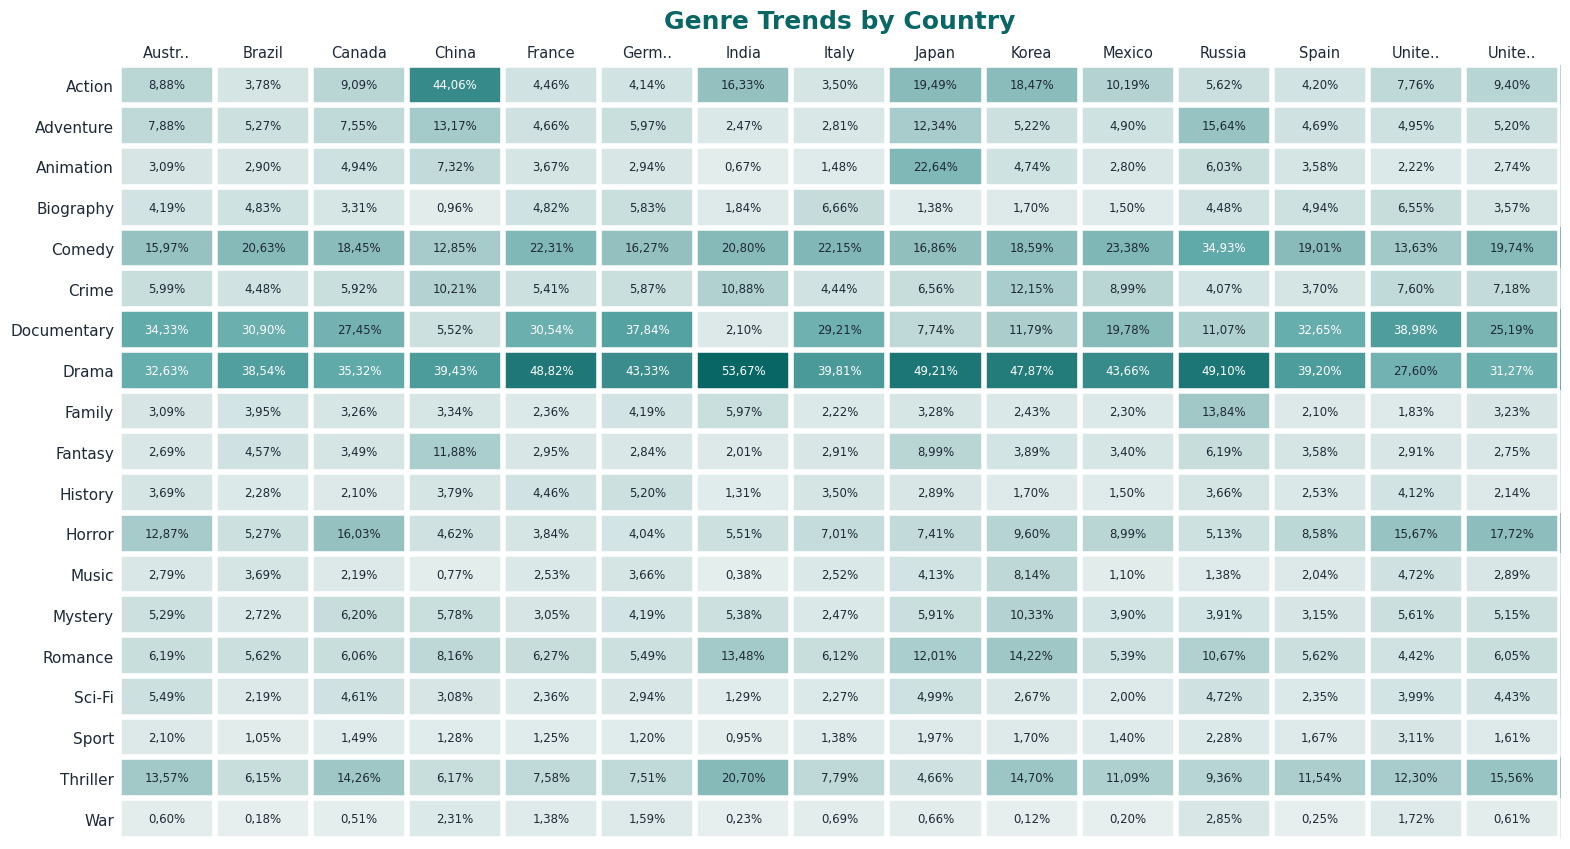

In [20]:
normalize_korea = lambda x: "Korea" if pd.notna(x) and "korea" in str(x).strip().lower() else x

genre_list = [
    "Action", "Adventure", "Animation", "Biography", "Comedy", "Crime",
    "Documentary", "Drama", "Family", "Fantasy", "History", "Horror",
    "Music", "Mystery", "Romance", "Sci-Fi", "Sport", "Thriller", "War"
]

country_list = [
    "Australia", "Brazil", "Canada", "China", "France", "Germany",
    "India", "Italy", "Japan", "Korea", "Mexico", "Russia",
    "Spain", "United Kingdom", "United States"
]

def short_country_label(name):
    mapping = {
        "Australia": "Austr..",
        "Germany": "Germ..",
        "United Kingdom": "Unite..",
        "United States": "Unite..",
    }
    return mapping.get(name, name)

heatmap_base = (
    movies_country[["ID", "Country_of_Origin"]]
    .merge(movies_genre[["ID", "Genre_Name"]], on="ID", how="inner")
    .copy()
)

heatmap_base["Country_of_Origin"] = heatmap_base["Country_of_Origin"].map(normalize_korea)
heatmap_base = clean_text_column(heatmap_base, "Country_of_Origin")
heatmap_base = clean_text_column(heatmap_base, "Genre_Name")

heatmap_base = heatmap_base[
    heatmap_base["Country_of_Origin"].isin(country_list) &
    heatmap_base["Genre_Name"].isin(genre_list)
].copy()

genre_country_count = (
    heatmap_base.groupby(["Genre_Name", "Country_of_Origin"], as_index=False)
    .agg(movie_count=("ID", "nunique"))
)

country_total_selected_genres = (
    heatmap_base.groupby("Country_of_Origin", as_index=False)
    .agg(country_total_movies=("ID", "nunique"))
)

genre_country_pct = genre_country_count.merge(
    country_total_selected_genres,
    on="Country_of_Origin",
    how="left"
)
genre_country_pct["pct"] = genre_country_pct["movie_count"] / genre_country_pct["country_total_movies"]

chart4_heatmap = (
    genre_country_pct.pivot(index="Genre_Name", columns="Country_of_Origin", values="pct")
    .reindex(index=genre_list, columns=country_list)
    .fillna(0)
)

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "teal_grad_d3_chart4",
    ["#E6EFEE", "#8CBDBC", "#5FAAAA", "#086665"]
)

values = chart4_heatmap.values
norm = mpl.colors.Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))

fig, ax = plt.subplots(figsize=(15.8, 8.6), facecolor=BG)
ax.set_facecolor(BG)

ax.imshow(values, aspect="auto", cmap=cmap, interpolation="nearest")

ax.set_title("Genre Trends by Country", fontsize=18, fontweight="bold", color="#086665", pad=12)
ax.set_xticks(np.arange(chart4_heatmap.shape[1]))
ax.set_xticklabels([short_country_label(c) for c in chart4_heatmap.columns], fontsize=10.5, color=TEXT_DARK)
ax.set_yticks(np.arange(chart4_heatmap.shape[0]))
ax.set_yticklabels(chart4_heatmap.index, fontsize=11, color=TEXT_DARK)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, length=0)

ax.set_xticks(np.arange(-0.5, chart4_heatmap.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, chart4_heatmap.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=4)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(chart4_heatmap.shape[0]):
    for j in range(chart4_heatmap.shape[1]):
        val = values[i, j]
        txt_color = "white" if norm(val) >= 0.55 else TEXT_DARK
        ax.text(
            j, i,
            f"{val*100:.2f}%".replace(".", ","),
            ha="center", va="center",
            fontsize=8.5, color=txt_color
        )

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# DASHBOARD 4: MOVIE STAR ANALYTICS

Chuẩn bị dữ liệu 

In [21]:
votes_col = "No_of_votes"
imdb_col = "IMDB_Rating"

movies_main["Released_Date"] = pd.to_datetime(movies_main["Released_Date"], errors="coerce")
movies_main["Year"] = movies_main["Released_Date"].dt.year

star_detail = (
    clean_text_column(movies_stars, "Star_Name")
    .merge(
        movies_main[["ID", "Year", "Weighted_Rating", votes_col, imdb_col]],
        on="ID",
        how="left"
    )
)

star_dashboard = (
    star_detail.groupby("Star_Name", as_index=False)
    .agg(
        TotalMovies=("ID", "nunique"),
        AvgWeightedRating=("Weighted_Rating", "mean"),
        NoVotes=(votes_col, "sum"),
        AvgIMDBRating=(imdb_col, "mean")
    )
    .sort_values(["TotalMovies", "Star_Name"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

top_star_order = star_dashboard["Star_Name"].tolist()

star_yearly = (
    star_detail[star_detail["Star_Name"].isin(top_star_order)]
    .dropna(subset=["Year"])
    .groupby(["Star_Name", "Year"], as_index=False)
    .agg(TotalMovies=("ID", "nunique"))
)

star_yearly_pivot = (
    star_yearly.pivot(index="Star_Name", columns="Year", values="TotalMovies")
    .reindex(top_star_order)
)

genre_base = clean_text_column(movies_genre, "Genre_Name")[["ID", "Genre_Name"]].copy()

genre_total = (
    genre_base.groupby("Genre_Name", as_index=False)
    .agg(Genre_Total_Movies=("ID", "nunique"))
)

genre_total["Genre_Grouped"] = np.where(
    genre_total["Genre_Total_Movies"] >= 1100,
    genre_total["Genre_Name"],
    "Others"
)

genre_base = genre_base.merge(
    genre_total[["Genre_Name", "Genre_Grouped"]],
    on="Genre_Name",
    how="left"
)

star_genre_detail = (
    clean_text_column(movies_stars, "Star_Name")[["ID", "Star_Name"]]
    .merge(
        genre_base[["ID", "Genre_Grouped"]],
        on="ID",
        how="inner"
    )
)

star_genre_summary = (
    star_genre_detail[star_genre_detail["Star_Name"].isin(top_star_order)]
    .groupby(["Star_Name", "Genre_Grouped"], as_index=False)
    .agg(TotalMovies=("ID", "nunique"))
)

star_genre_pivot = (
    star_genre_summary.pivot(index="Star_Name", columns="Genre_Grouped", values="TotalMovies")
    .reindex(top_star_order)
)

star_genre_pivot = star_genre_pivot.reindex(sorted(star_genre_pivot.columns), axis=1)
if "Others" in star_genre_pivot.columns:
    star_genre_pivot = star_genre_pivot.drop(columns="Others")

total_stars = clean_text_column(movies_stars, "Star_Name")["Star_Name"].nunique()

Chart 1: KPI Total Stars

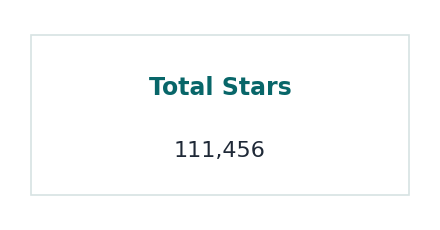

In [22]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

fig, ax = plt.subplots(figsize=(4.5, 2.4), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

card = plt.Rectangle(
    (0.05, 0.12), 0.90, 0.76,
    transform=ax.transAxes,
    facecolor="white",
    edgecolor="#D7E3E3",
    linewidth=1.2
)
ax.add_patch(card)

ax.text(
    0.5, 0.63, "Total Stars",
    ha="center", va="center",
    fontsize=17, fontweight="bold",
    color=THEME, transform=ax.transAxes
)

ax.text(
    0.5, 0.33, f"{total_stars:,}",
    ha="center", va="center",
    fontsize=16, color=TEXT_DARK,
    transform=ax.transAxes
)

plt.tight_layout()
plt.show()

Chart 2: Top 10 Stars by Movies

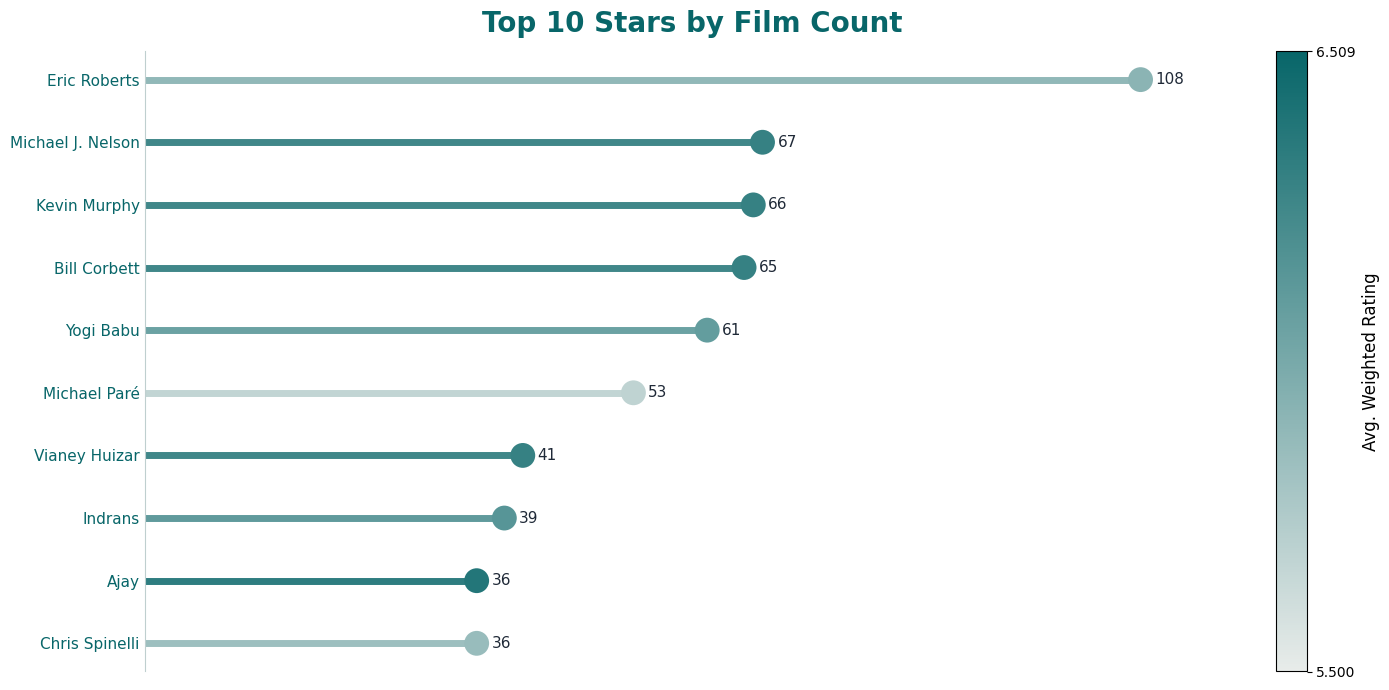

In [23]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

WR_VMIN = 5.5
WR_VMAX = 6.508922410

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "wr_map_dash4_star_top10",
    ["#E8ECEA", THEME]
)
wr_norm = mpl.colors.Normalize(vmin=WR_VMIN, vmax=WR_VMAX)

star_summary = (
    clean_text_column(movies_stars, "Star_Name")
    .merge(
        movies_main[["ID", "Weighted_Rating"]],
        on="ID",
        how="left"
    )
    .groupby("Star_Name", as_index=False)
    .agg(
        movie_count=("ID", "nunique"),
        avg_rating=("Weighted_Rating", "mean")
    )
    .sort_values(["movie_count", "Star_Name"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

plot_df = star_summary.sort_values("movie_count", ascending=False).reset_index(drop=True)
y = np.arange(len(plot_df))
colors = [cmap(wr_norm(v)) for v in plot_df["avg_rating"]]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_facecolor(BG)

ax.hlines(y=y, xmin=0, xmax=plot_df["movie_count"], color=colors, linewidth=5, alpha=0.95, zorder=2)
ax.scatter(plot_df["movie_count"], y, s=320, color=colors, edgecolor="none", zorder=3)

offset = plot_df["movie_count"].max() * 0.015
for yi, xi in zip(y, plot_df["movie_count"]):
    ax.text(
        xi + offset, yi,
        f"{int(xi):,}",
        va="center", ha="left",
        fontsize=11, color=TEXT_DARK
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Star_Name"], fontsize=11, color=THEME)
ax.set_title("Top 10 Stars by Film Count", fontsize=20, fontweight="bold", color=THEME, pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#BFCFCF")

ax.set_xticks([])
ax.tick_params(axis="y", length=0)
ax.grid(False)
ax.invert_yaxis()
ax.set_xlim(0, plot_df["movie_count"].max() * 1.10)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=wr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Avg. Weighted Rating", fontsize=12)
cbar.set_ticks([WR_VMIN, WR_VMAX])
cbar.set_ticklabels([f"{WR_VMIN:.3f}", f"{WR_VMAX:.3f}"])

plt.tight_layout()
plt.show()

Chart 3: Audience Reach vs Rating of Top Stars

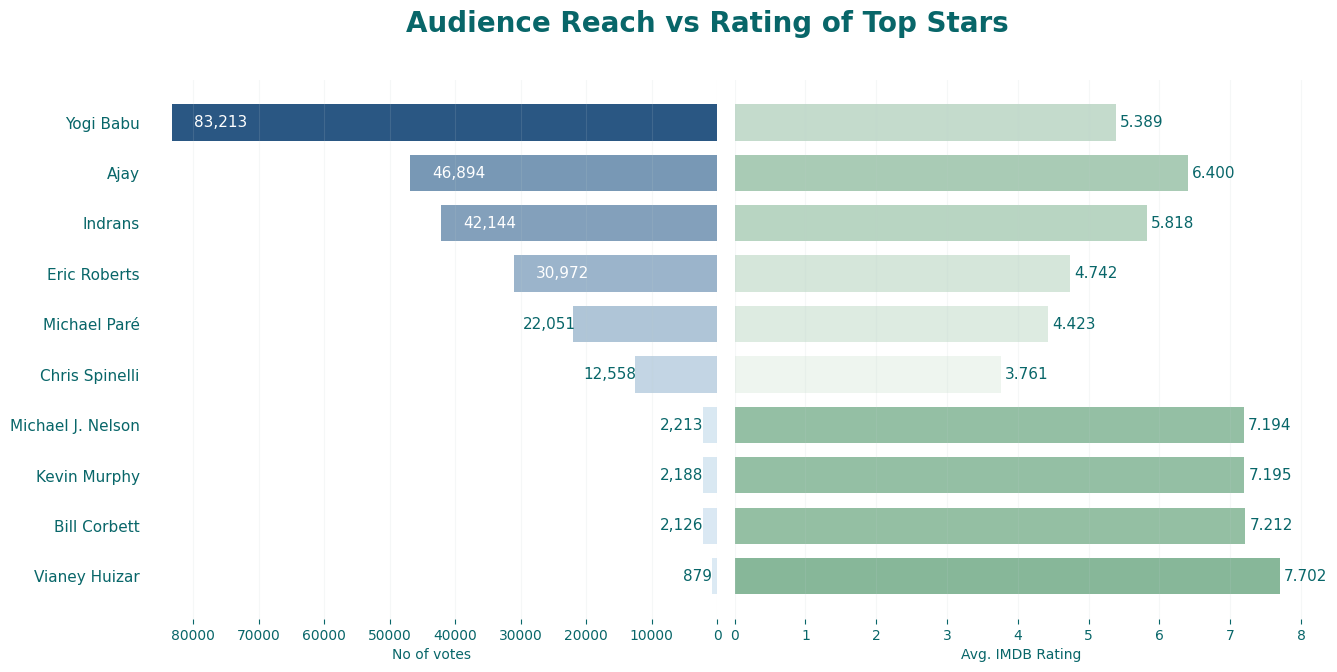

In [55]:
THEME = "#086669"
BG = "white"
C_GREEN = "#87B799"
C_BLUE1 = "#2A5783"

votes_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "votes_cmap_dash4",
    ["#DCEAF4", C_BLUE1]
)
imdb_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "imdb_cmap_dash4",
    ["#EEF5EF", C_GREEN]
)

votes_norm = mpl.colors.Normalize(
    vmin=star_dashboard["NoVotes"].min(),
    vmax=star_dashboard["NoVotes"].max()
)
imdb_norm = mpl.colors.Normalize(
    vmin=star_dashboard["AvgIMDBRating"].min(),
    vmax=star_dashboard["AvgIMDBRating"].max()
)

chart3 = star_dashboard.sort_values("NoVotes", ascending=False).copy()

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.03},
    sharey=True,
    facecolor=BG
)

ax1.set_facecolor(BG)
ax2.set_facecolor(BG)

vote_colors = votes_cmap(votes_norm(chart3["NoVotes"]))
imdb_colors = imdb_cmap(imdb_norm(chart3["AvgIMDBRating"]))

ax1.barh(chart3["Star_Name"], chart3["NoVotes"], color=vote_colors, height=0.72)
ax1.invert_xaxis()
ax1.invert_yaxis()

max_votes = chart3["NoVotes"].max()

for row in chart3.itertuples(index=False):
    if row.NoVotes >= max_votes * 0.35:
        x_text = row.NoVotes - max_votes * 0.04
        ha_text = "left"
        txt_color = "white"
    else:
        x_text = row.NoVotes * 0.98
        ha_text = "right"
        txt_color = THEME

    ax1.text(
        x_text,
        row.Star_Name,
        f"{int(row.NoVotes):,}",
        ha=ha_text,
        va="center",
        fontsize=11,
        color=txt_color,
        clip_on=False
    )

fig.suptitle(
    "Audience Reach vs Rating of Top Stars",
    fontsize=20,
    fontweight="bold",
    color=THEME,
    x=0.5,
    y=0.98
)
ax1.set_xlabel("No of votes", color=THEME)
ax1.set_ylabel("")
ax1.tick_params(axis="y", colors=THEME, labelsize=11, length=0)
ax1.tick_params(axis="x", colors=THEME)

ax2.barh(chart3["Star_Name"], chart3["AvgIMDBRating"], color=imdb_colors, height=0.72)

for row in chart3.itertuples(index=False):
    ax2.text(
        row.AvgIMDBRating + 0.06,
        row.Star_Name,
        f"{row.AvgIMDBRating:.3f}",
        ha="left",
        va="center",
        fontsize=11,
        color=THEME
    )

ax2.set_xlabel("Avg. IMDB Rating", color=THEME)
ax2.tick_params(axis="y", left=False, labelleft=False)
ax2.tick_params(axis="x", colors=THEME)

for ax in [ax1, ax2]:
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="x", alpha=0.15, color="#BFCFCF")

fig.subplots_adjust(top=0.88, wspace=0.03)
plt.show()

Chart 4: Yearly Film Presence of Top Stars

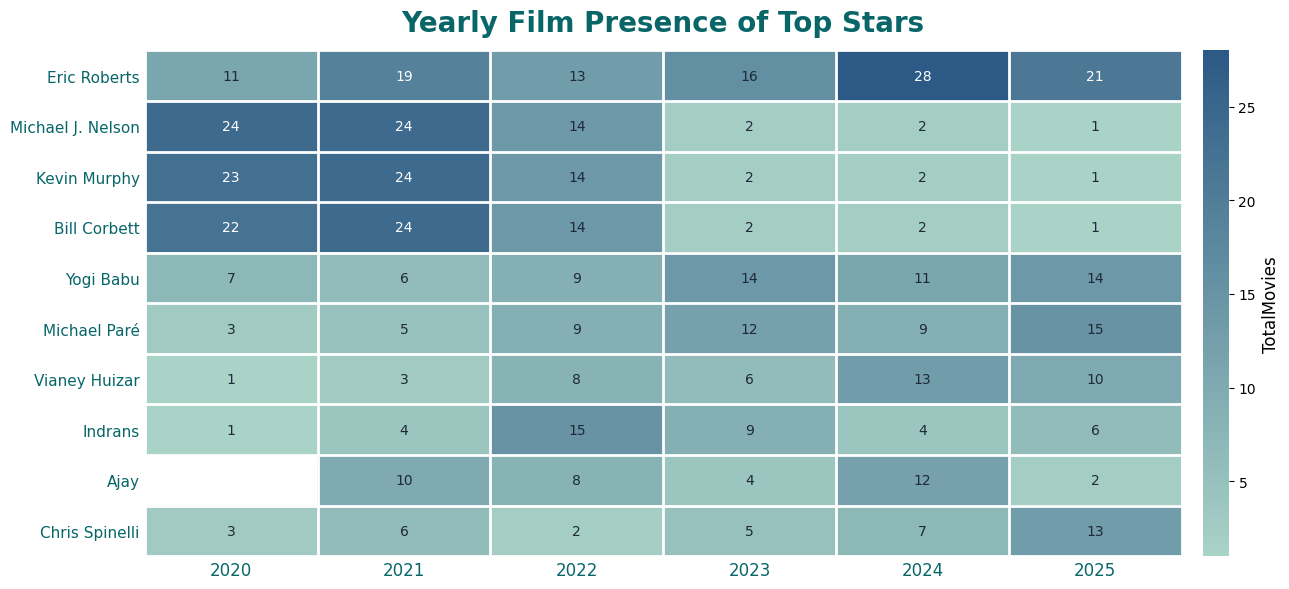

In [25]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

fig, ax = plt.subplots(figsize=(13, 6), facecolor=BG)
ax.set_facecolor(BG)

cmap_yearly = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_yearly_dash4",
    ["#A9D3C7", "#2C5985"]
)
cmap_yearly.set_bad(color="white")

arr = star_yearly_pivot.values.astype(float)
masked_arr = np.ma.masked_invalid(arr)

vmin = np.nanmin(arr)
vmax = np.nanmax(arr)

im = ax.imshow(
    masked_arr,
    aspect="auto",
    cmap=cmap_yearly,
    vmin=vmin,
    vmax=vmax
)

ax.set_xticks(np.arange(star_yearly_pivot.shape[1]))
ax.set_yticks(np.arange(star_yearly_pivot.shape[0]))

ax.set_xticklabels(star_yearly_pivot.columns.astype(int), fontsize=12, color=THEME)
ax.set_yticklabels(star_yearly_pivot.index, fontsize=11, color=THEME)

ax.set_title(
    "Yearly Film Presence of Top Stars",
    fontsize=20,
    fontweight="bold",
    color=THEME,
    pad=14
)

ax.set_xticks(np.arange(-0.5, star_yearly_pivot.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, star_yearly_pivot.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(length=0)

for i in range(star_yearly_pivot.shape[0]):
    for j in range(star_yearly_pivot.shape[1]):
        val = star_yearly_pivot.iloc[i, j]
        if pd.notna(val):
            txt_color = "white" if val >= vmax * 0.65 else TEXT_DARK
            ax.text(
                j, i, f"{int(val):,}",
                ha="center", va="center",
                fontsize=10, color=txt_color
            )

for s in ax.spines.values():
    s.set_visible(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("TotalMovies", fontsize=12)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

Chart 5: Genre Focus of Top Stars

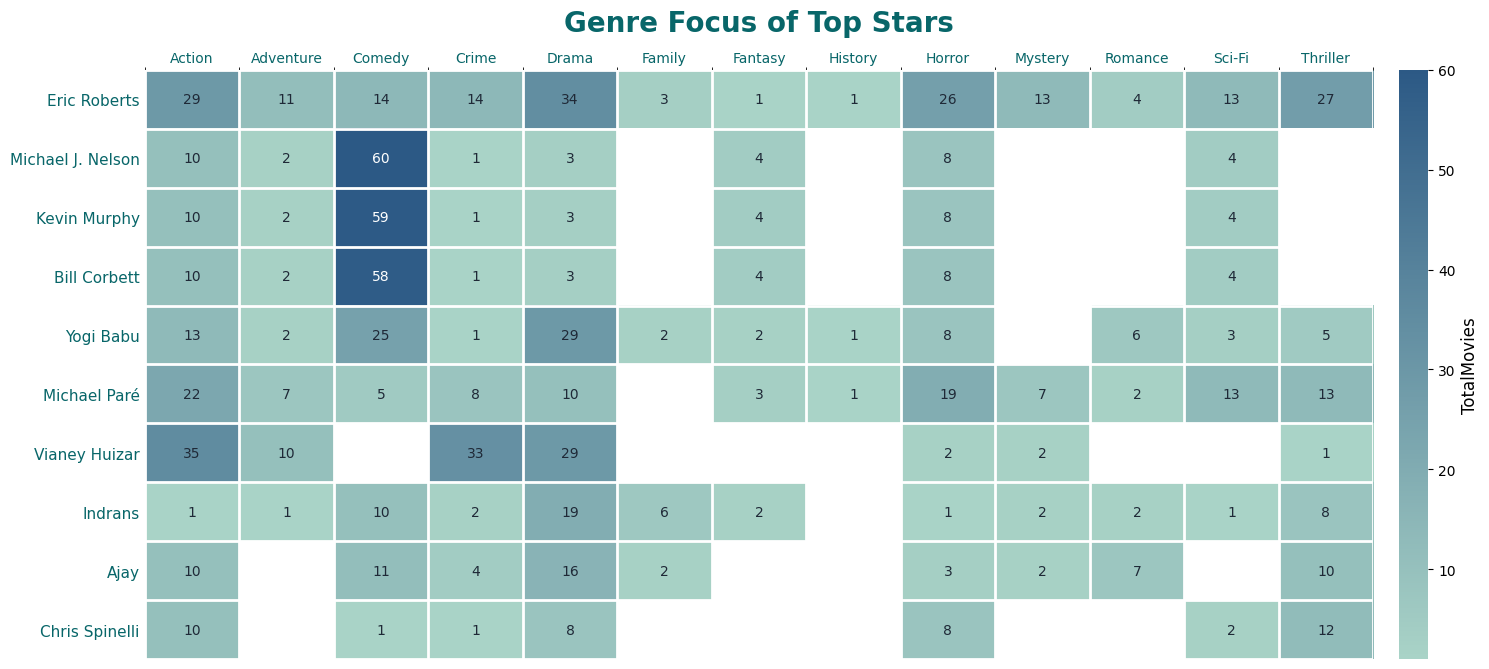

In [26]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

fig, ax = plt.subplots(figsize=(15, 6.8), facecolor=BG)
ax.set_facecolor(BG)

genre_plot = star_genre_pivot.copy()
genre_plot = genre_plot.drop(columns=["Animation", "Biography", "Music", "Documentary"], errors="ignore")
genre_plot = genre_plot.reindex(sorted(genre_plot.columns), axis=1)

genre_plot = genre_plot.astype(float)
genre_plot = genre_plot.mask(genre_plot == 0)

cmap_genre = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_genre_dash4",
    ["#A9D3C7", "#2C5985"]
)
cmap_genre.set_bad(color="white")

arr = genre_plot.values.astype(float)
masked_arr = np.ma.masked_invalid(arr)

vmin = np.nanmin(arr)
vmax = np.nanmax(arr)

im = ax.imshow(
    masked_arr,
    aspect="auto",
    cmap=cmap_genre,
    vmin=vmin,
    vmax=vmax
)

ax.set_xticks(np.arange(genre_plot.shape[1]))
ax.set_yticks(np.arange(genre_plot.shape[0]))

ax.set_xticklabels(genre_plot.columns, fontsize=10, color=THEME)
ax.set_yticklabels(genre_plot.index, fontsize=11, color=THEME)

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False, length=0)
ax.tick_params(axis="y", length=0)

ax.set_title(
    "Genre Focus of Top Stars",
    fontsize=20,
    fontweight="bold",
    color=THEME,
    pad=28
)

ax.set_xticks(np.arange(-0.5, genre_plot.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, genre_plot.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(genre_plot.shape[0]):
    for j in range(genre_plot.shape[1]):
        val = genre_plot.iloc[i, j]
        if pd.notna(val):
            txt_color = "white" if val >= vmax * 0.65 else TEXT_DARK
            ax.text(
                j, i, f"{int(val):,}",
                ha="center", va="center",
                fontsize=10, color=txt_color
            )

for s in ax.spines.values():
    s.set_visible(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("TotalMovies", fontsize=12)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

# DASHBOARD 5: MOVIE DIRECTORS ANALYTICS

Chuẩn bị dữ liệu

In [43]:
# ===== chuẩn bị dữ liệu Genre Focus cho DASH 5: directors =====

director_genre_detail = (
    clean_text_column(movies_director, "Director_Name")[["ID", "Director_Name"]]
    .merge(
        clean_text_column(movies_genre, "Genre_Name")[["ID", "Genre_Name"]],
        on="ID",
        how="inner"
    )
)

director_genre_summary = (
    director_genre_detail[director_genre_detail["Director_Name"].isin(top_director_order)]
    .groupby(["Director_Name", "Genre_Name"], as_index=False)
    .agg(TotalMovies=("ID", "nunique"))
)

director_genre_pivot = (
    director_genre_summary.pivot(
        index="Director_Name",
        columns="Genre_Name",
        values="TotalMovies"
    )
    .reindex(top_director_order)
)

Chart 1: KPI Total Directors

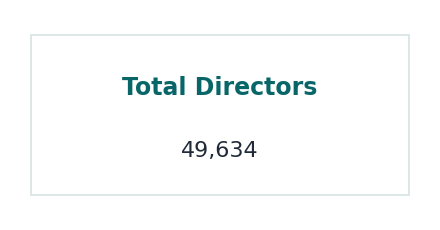

In [44]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

fig, ax = plt.subplots(figsize=(4.5, 2.4), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

card = plt.Rectangle(
    (0.05, 0.12), 0.90, 0.76,
    transform=ax.transAxes,
    facecolor="white",
    edgecolor="#D7E3E3",
    linewidth=1.2
)
ax.add_patch(card)

ax.text(
    0.5, 0.63, "Total Directors",
    ha="center", va="center",
    fontsize=17, fontweight="bold",
    color=THEME, transform=ax.transAxes
)

ax.text(
    0.5, 0.33, f"{total_directors:,}",
    ha="center", va="center",
    fontsize=16, color=TEXT_DARK,
    transform=ax.transAxes
)

plt.tight_layout()
plt.show()

Chart 2: Top 10 Directors by Film Count

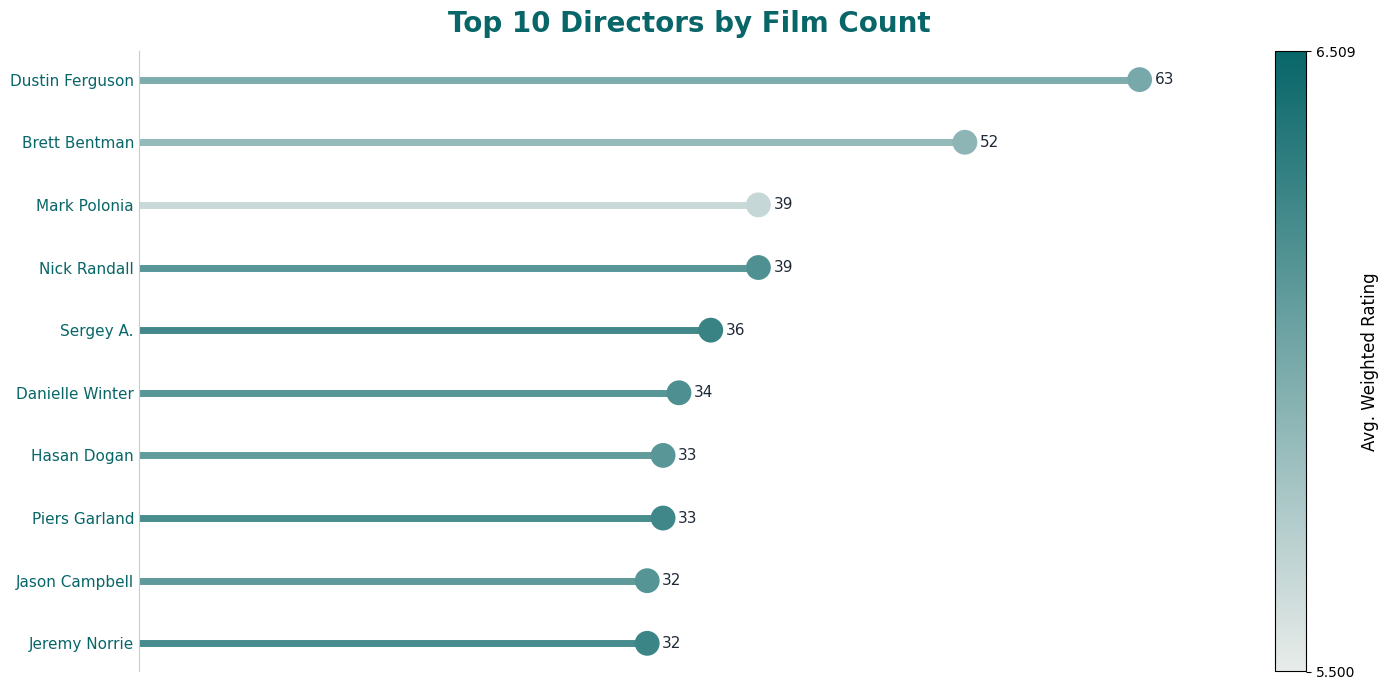

In [45]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

WR_VMIN = 5.5
WR_VMAX = 6.508922410

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "wr_map_dash5_director_top10",
    ["#E8ECEA", THEME]
)
wr_norm = mpl.colors.Normalize(vmin=WR_VMIN, vmax=WR_VMAX)

director_summary = (
    clean_text_column(movies_director, "Director_Name")
    .merge(
        movies_main[["ID", "Weighted_Rating"]],
        on="ID",
        how="left"
    )
    .groupby("Director_Name", as_index=False)
    .agg(
        movie_count=("ID", "nunique"),
        avg_rating=("Weighted_Rating", "mean")
    )
    .sort_values(["movie_count", "Director_Name"], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

plot_df = director_summary.sort_values("movie_count", ascending=False).reset_index(drop=True)
y = np.arange(len(plot_df))
colors = [cmap(wr_norm(v)) for v in plot_df["avg_rating"]]

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
ax.set_facecolor(BG)

ax.hlines(y=y, xmin=0, xmax=plot_df["movie_count"], color=colors, linewidth=5, alpha=0.95, zorder=2)
ax.scatter(plot_df["movie_count"], y, s=320, color=colors, edgecolor="none", zorder=3)

offset = plot_df["movie_count"].max() * 0.015
for yi, xi in zip(y, plot_df["movie_count"]):
    ax.text(
        xi + offset, yi,
        f"{int(xi):,}",
        va="center", ha="left",
        fontsize=11, color=TEXT_DARK
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Director_Name"], fontsize=11, color=THEME)
ax.set_title("Top 10 Directors by Film Count", fontsize=20, fontweight="bold", color=THEME, pad=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#BFCFCF")

ax.set_xticks([])
ax.tick_params(axis="y", length=0)
ax.grid(False)
ax.invert_yaxis()
ax.set_xlim(0, plot_df["movie_count"].max() * 1.10)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=wr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Avg. Weighted Rating", fontsize=12)
cbar.set_ticks([WR_VMIN, WR_VMAX])
cbar.set_ticklabels([f"{WR_VMIN:.3f}", f"{WR_VMAX:.3f}"])

plt.tight_layout()
plt.show()

Chart 3: Audience Reach vs Rating of Top Directors

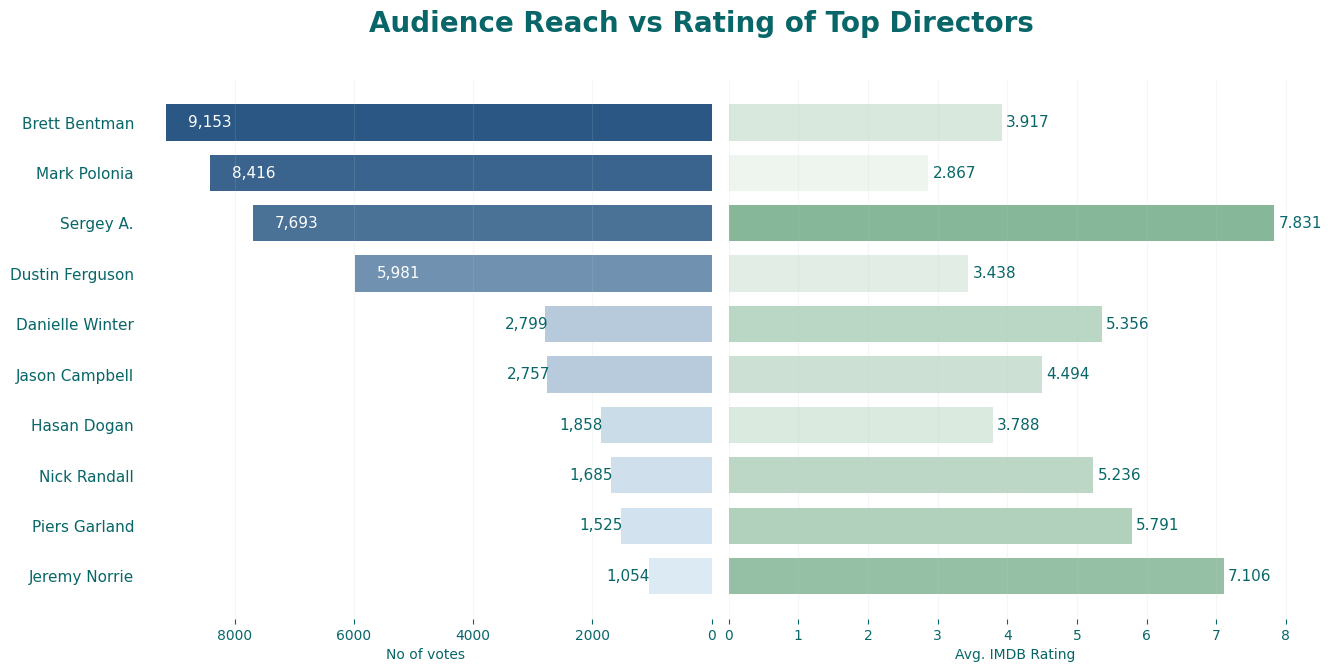

In [56]:
THEME = "#086669"
BG = "white"
C_GREEN = "#87B799"
C_BLUE1 = "#2A5783"

votes_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "votes_cmap_dash5",
    ["#DCEAF4", C_BLUE1]
)
imdb_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "imdb_cmap_dash5",
    ["#EEF5EF", C_GREEN]
)

votes_norm_dir = mpl.colors.Normalize(
    vmin=director_dashboard["NoVotes"].min(),
    vmax=director_dashboard["NoVotes"].max()
)
imdb_norm_dir = mpl.colors.Normalize(
    vmin=director_dashboard["AvgIMDBRating"].min(),
    vmax=director_dashboard["AvgIMDBRating"].max()
)

chart3 = director_dashboard.sort_values("NoVotes", ascending=False).copy()

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.03},
    sharey=True,
    facecolor=BG
)

ax1.set_facecolor(BG)
ax2.set_facecolor(BG)

vote_colors = votes_cmap(votes_norm_dir(chart3["NoVotes"]))
imdb_colors = imdb_cmap(imdb_norm_dir(chart3["AvgIMDBRating"]))

ax1.barh(chart3["Director_Name"], chart3["NoVotes"], color=vote_colors, height=0.72)
ax1.invert_xaxis()
ax1.invert_yaxis()

max_votes = chart3["NoVotes"].max()

for row in chart3.itertuples(index=False):
    if row.NoVotes >= max_votes * 0.35:
        x_text = row.NoVotes - max_votes * 0.04
        ha_text = "left"
        txt_color = "white"
    else:
        x_text = row.NoVotes * 0.98
        ha_text = "right"
        txt_color = THEME

    ax1.text(
        x_text,
        row.Director_Name,
        f"{int(row.NoVotes):,}",
        ha=ha_text,
        va="center",
        fontsize=11,
        color=txt_color,
        clip_on=False
    )

fig.suptitle(
    "Audience Reach vs Rating of Top Directors",
    fontsize=20,
    fontweight="bold",
    color=THEME,
    x=0.5,
    y=0.98
)
ax1.set_xlabel("No of votes", color=THEME)
ax1.set_ylabel("")
ax1.tick_params(axis="y", colors=THEME, labelsize=11, length=0)
ax1.tick_params(axis="x", colors=THEME)

ax2.barh(chart3["Director_Name"], chart3["AvgIMDBRating"], color=imdb_colors, height=0.72)

for row in chart3.itertuples(index=False):
    ax2.text(
        row.AvgIMDBRating + 0.06,
        row.Director_Name,
        f"{row.AvgIMDBRating:.3f}",
        ha="left",
        va="center",
        fontsize=11,
        color=THEME
    )

ax2.set_xlabel("Avg. IMDB Rating", color=THEME)
ax2.tick_params(axis="y", left=False, labelleft=False)
ax2.tick_params(axis="x", colors=THEME)

for ax in [ax1, ax2]:
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="x", alpha=0.15, color="#BFCFCF")

fig.subplots_adjust(top=0.88, wspace=0.03)
plt.show()

Chart 4: Yearly Film Presence of Top Directors

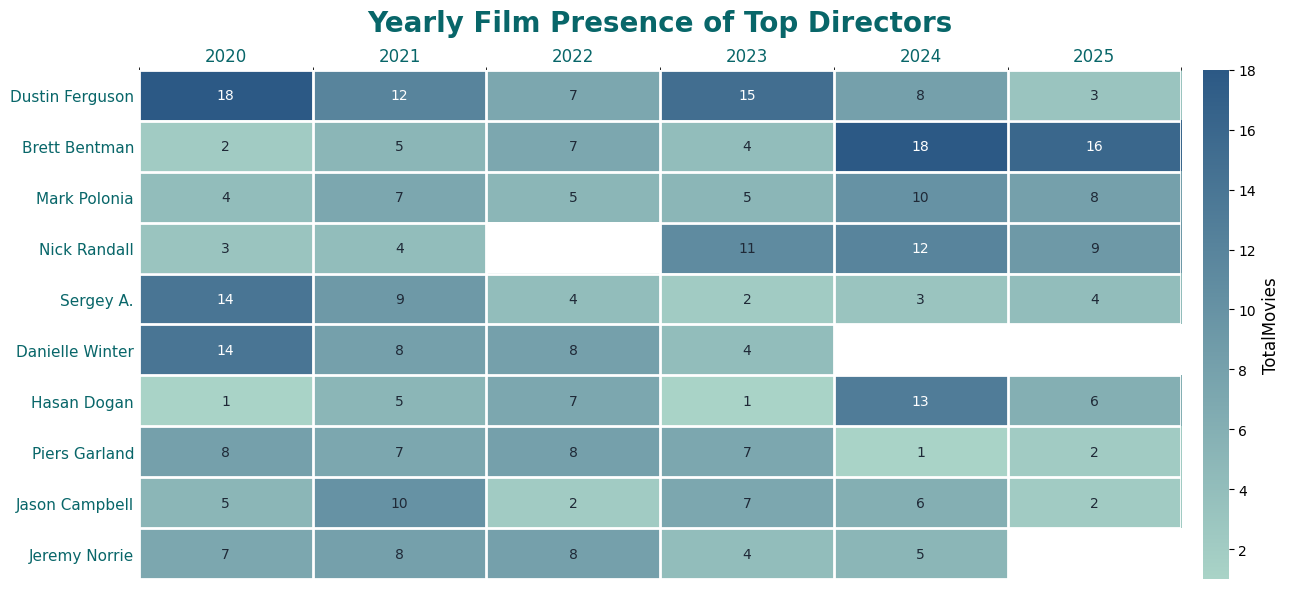

In [47]:
THEME = "#086669"
TEXT_DARK = "#1F2937"
BG = "white"

fig, ax = plt.subplots(figsize=(13, 6), facecolor=BG)
ax.set_facecolor(BG)

cmap_yearly = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_yearly_dash5",
    ["#A9D3C7", "#2C5985"]
)
cmap_yearly.set_bad(color="white")

arr = director_yearly_pivot.values.astype(float)
masked_arr = np.ma.masked_invalid(arr)

vmin = np.nanmin(arr)
vmax = np.nanmax(arr)

im = ax.imshow(
    masked_arr,
    aspect="auto",
    cmap=cmap_yearly,
    vmin=vmin,
    vmax=vmax
)

ax.set_xticks(np.arange(director_yearly_pivot.shape[1]))
ax.set_yticks(np.arange(director_yearly_pivot.shape[0]))

ax.set_xticklabels(director_yearly_pivot.columns.astype(int), fontsize=12, color=THEME)
ax.set_yticklabels(director_yearly_pivot.index, fontsize=11, color=THEME)

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False, length=0)
ax.tick_params(axis="y", length=0)

ax.set_title(
    "Yearly Film Presence of Top Directors",
    fontsize=20,
    fontweight="bold",
    color=THEME,
    pad=28
)

ax.set_xticks(np.arange(-0.5, director_yearly_pivot.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, director_yearly_pivot.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(director_yearly_pivot.shape[0]):
    for j in range(director_yearly_pivot.shape[1]):
        val = director_yearly_pivot.iloc[i, j]
        if pd.notna(val):
            txt_color = "white" if val >= vmax * 0.65 else TEXT_DARK
            ax.text(
                j, i, f"{int(val):,}",
                ha="center", va="center",
                fontsize=10, color=txt_color
            )

for s in ax.spines.values():
    s.set_visible(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("TotalMovies", fontsize=12)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

Chart 5: Genre Focus of Top Directors

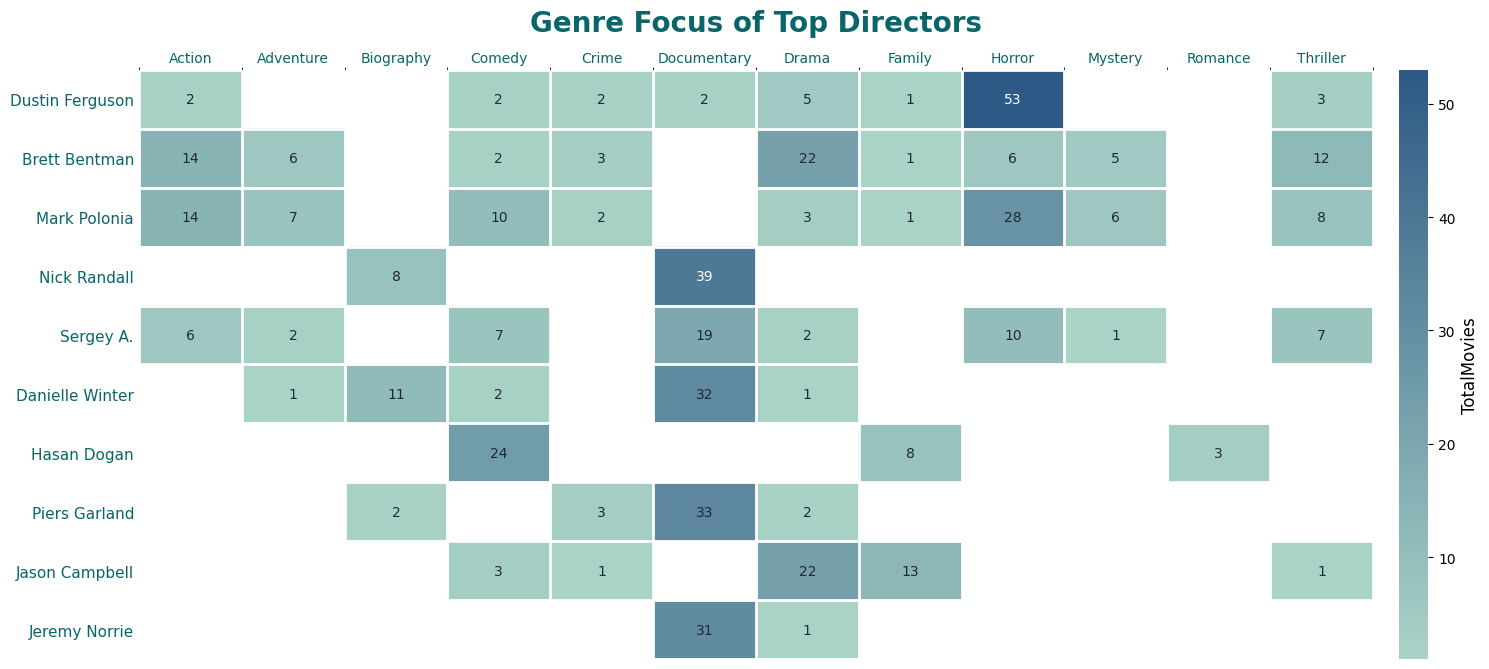

In [50]:
fig, ax = plt.subplots(figsize=(15, 6.8), facecolor=BG)
ax.set_facecolor(BG)

# Lấy TOP 12 genre có total movies cao nhất từ toàn bộ dữ liệu
top12_genres = (
    clean_text_column(movies_genre, "Genre_Name")
    .groupby("Genre_Name", as_index=False)
    .agg(TotalMovies=("ID", "nunique"))
    .sort_values(["TotalMovies", "Genre_Name"], ascending=[False, True])
    .head(12)["Genre_Name"]
    .tolist()
)

# Sắp xếp 12 genre theo Alphabet
top12_genres = sorted(top12_genres)

# Giữ nguyên pivot gốc, chỉ lọc lại theo top 12 genre
genre_plot = director_genre_pivot.copy()

for col in top12_genres:
    if col not in genre_plot.columns:
        genre_plot[col] = np.nan

genre_plot = genre_plot[top12_genres]

# đổi 0 thành NaN để ô trống là màu trắng
genre_plot = genre_plot.astype(float)
genre_plot = genre_plot.mask(genre_plot == 0)

cmap_genre = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_genre_director",
    ["#A9D3C7", "#2C5985"]
)
cmap_genre.set_bad(color="white")

arr = genre_plot.values.astype(float)
masked_arr = np.ma.masked_invalid(arr)

vmin = np.nanmin(arr)
vmax = np.nanmax(arr)

im = ax.imshow(
    masked_arr,
    aspect="auto",
    cmap=cmap_genre,
    vmin=vmin,
    vmax=vmax
)

ax.set_xticks(np.arange(genre_plot.shape[1]))
ax.set_yticks(np.arange(genre_plot.shape[0]))

ax.set_xticklabels(genre_plot.columns, fontsize=10, color=THEME)
ax.set_yticklabels(genre_plot.index, fontsize=11, color=THEME)

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False, length=0)

ax.set_title(
    "Genre Focus of Top Directors",
    fontsize=20,
    fontweight="bold",
    color=THEME,
    pad=28
)

ax.set_xticks(np.arange(-0.5, genre_plot.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, genre_plot.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

ax.tick_params(axis="y", length=0)

for i in range(genre_plot.shape[0]):
    for j in range(genre_plot.shape[1]):
        val = genre_plot.iloc[i, j]
        if pd.notna(val):
            txt_color = "white" if val >= vmax * 0.65 else TEXT_DARK
            ax.text(
                j, i, f"{int(val):,}",
                ha="center", va="center",
                fontsize=10, color=txt_color
            )

for s in ax.spines.values():
    s.set_visible(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("TotalMovies", fontsize=12)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()